In [1]:
!pip install itscalledsoccer 'plotnine[all]' colour --quiet

In [2]:
from itscalledsoccer.client import AmericanSoccerAnalysis
from plotnine import *
from colour import Color
import numpy as np
import pandas as pd

asa_client = AmericanSoccerAnalysis()

In [3]:
asa_client.get_teams(leagues="nwsl")

,team_id,team_name,team_short_name,team_abbreviation,competition
0,315VnJ759x,Bay FC,Bay FC,BAY,nwsl
1,4JMAk47qKg,Houston Dash,Houston,HOU,nwsl
2,4wM4Ezg5jB,Boston Breakers,Boston,BOS,nwsl
3,4wM4rZdqjB,Kansas City Current,Kansas City,KC,nwsl
4,7vQ7BBzqD1,Seattle Reign FC,Seattle,SEA,nwsl
5,7VqG1lYMvW,San Diego Wave FC,San Diego,SD,nwsl
6,aDQ0lzvQEv,Washington Spirit,Washington,WAS,nwsl
7,eV5D2w9QKn,Utah Royals FC,Utah Royals,UTA,nwsl
8,eV5DR6YQKn,Racing Louisville FC,Louisville,LOU,nwsl
9,KPqjw8PQ6v,Chicago Stars FC,Chicago,CHI,nwsl


In [4]:
nwsl_team_colors = {
    "HOU": ["#FF6900", "#8BB8E8", "#101820"],  # Electric Orange, Space City Blue, Black
    "KC": ["#CB333B", "#64CCC9", "#091F2C"],  # Red, Teal, Blue
    "SD": ["#041E42", "#00C1D4", "#E31C79"],  # Dark Blue, Cyan, Pink
    "SEA": ["#003087", "#D22730", "#CC8A00"],  # Blue, Red, Gold
    "WAS": ["#C8102E", "#051C2C", "#BBBCBC"],  # Strong Red, Dark Blue, Cool Gray
    "POR": ["#93282C", "#215732", "#010101"],  # Red, Green, Black
    "CHI": ["#051C2C", "#41B6E6", "#C8102E"],  # Navy, Light Blue, Red
    "LOU": ["#C5B4E3", "#1E1A34", "#BDE9C9"],  # Lavender, Deep Violet, Mint Green
    "LA": ["#F2D4D7", "#010101", "#D0D0CE"],  # Sol Rosa, Asphalt, Armour
    "NJY": ["#9ADBE8", "#010101", "#FFFFFF"],  # Sky Blue, Gotham Black, Cloud White
    "NC": [
        "#01426A",
        "#A50034",
        "#B3A369",
    ],  # Atlantic Blue, Cardinal Red, Southern Gold
    "ORL": ["#5F249F", "#00A9E0", "#FFFFFF"],  # Purple, Light Blue, White
    "UTA": ["#001E62", "#9D2235", "#FFB81C"],  # Cobalt Blue, Claret Red, Victory Gold
    "BAY": ["#051C2C", "#F9423A", "#DBE2E9"],  # Bay, Poppy, Fog Gray
}

In [5]:
nwsl_primary_colors = {
    "HOU": "#FF6900",  # Houston Dash - Electric Orange
    "KC": "#CB333B",  # Kansas City Current - Red
    "SD": "#E31C79",  # San Diego Wave FC - Pink
    "SEA": "#003087",  # Seattle Reign FC - Blue
    "WAS": "#051C2C",  # Washington Spirit - Dark Blue
    "POR": "#93282C",  # Portland Thorns FC - Red
    "CHI": "#C8102E",  # Chicago Red Stars - Red
    "LOU": "#C5B4E3",  # Racing Louisville FC - Lavender
    # 'LOU': '#1E1A34',  # Racing Louisville FC - Lavender
    "LA": "#F2D4D7",  # Angel City FC - Sol Rosa
    # 'LA': '#F2D4D7',   # Angel City FC - Sol Rosa
    # "NJY": "#9ADBE8",  # NJ/NY Gotham FC - Sky Blue
    "NJY": "#010101",  # Gotham Black
    "NC": "#01426A",  # North Carolina Courage - Atlantic Blue
    "ORL": "#5F249F",  # Orlando Pride - Purple
    "UTA": "#001E62",  # Utah Royals FC - Cobalt Blue
    "BAY": "#051C2C",  # Bay FC - Bay
}

In [6]:
from plotnine.geoms import geom
from plotnine.doctools import document
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image
import urllib

import matplotlib.pyplot as plt


@document
class geom_image(geom_point):
    """
    Plot Images with plotnine
    Based on geom_point
    Instead of points, plots images at those points

    Args:
        geom : ggplot geom
    """

    DEFAULT_AES = {"size": 0.1}  # , "color": None, "fill": "#333333",
    # "linetype": "solid", "size": 0.5 }
    DEFAULT_PARAMS = {
        "stat": "identity",
        "position": "identity",
        "na_rm": False,
    }  # no idea if I need this
    REQUIRED_AES = {"x", "y", "image"}  # just need an image column

    def draw_panel(self, data, panel_params, coord, ax, **params):
        """
        assume only one image per panel,
        """
        data = coord.transform(data, panel_params)
        self.draw_unit(data, panel_params, coord, ax, **params)

    @staticmethod
    def draw_group(data, panel_params, coord, ax, **params):
        data = coord.transform(data, panel_params)
        units = "shape"
        for _, udata in data.groupby(units, dropna=False):
            udata.reset_index(inplace=True, drop=True)
            geom_image.draw_unit(udata, panel_params, coord, ax, **params)

    @staticmethod
    def draw_unit(data, panel_params, coord, ax, **params):
        for i in range(len(data)):
            img = data["image"].iloc[i]
            zoom = data["size"].iloc[i]
            ab = AnnotationBbox(
                OffsetImage(
                    np.array(Image.open(urllib.request.urlopen(img))), zoom=zoom
                ),
                (data["x"].iloc[i], data["y"].iloc[i]),
                frameon=False,
                box_alignment=(0.5, 0),
            )
            ax.add_artist(ab)

In [7]:
asa_client.get_games(seasons="2025", leagues="nwsl", team_names="Racing Louisville FC")

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,expanded_minutes,season_name,matchday,attendance,knockout_game,status,last_updated_utc
0,vzqoKNrkqa,2025-06-21 00:00:00 UTC,2,0,eV5DR6YQKn,XVqKeVKM01,7VqGdjdQvW,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,100,2025,13,5469,False,FullTime,2025-06-21 02:15:41 UTC
1,7VqGbYm65v,2025-06-14 23:30:00 UTC,4,2,4wM4rZdqjB,eV5DR6YQKn,KPqj32nQ6v,xW5p3L0Mg1,vzqo3mNqap,kRQa4GoqKZ,103,2025,12,11500,False,FullTime,2025-06-19 06:21:07 UTC
2,p6qbjWeBq0,2025-06-07 00:34:00 UTC,3,2,eV5DR6YQKn,eV5D2w9QKn,e7Mz8Eeqr0,BLMvra8Mxe,kRQa4GoqKZ,9vQ2YGaqK6,98,2025,11,3951,False,FullTime,2025-06-07 02:38:19 UTC
3,BLMvj2lOMx,2025-05-25 02:00:00 UTC,2,3,kRQa8JOqKZ,eV5DR6YQKn,eVq3J465WO,7vQ7xbOMD1,9YqdZ39MvJ,kRQa4GoqKZ,104,2025,10,16740,False,FullTime,2025-05-31 17:29:53 UTC
4,KXMeZ6er56,2025-05-17 17:00:00 UTC,0,1,eV5DR6YQKn,7vQ7BBzqD1,NWMWpvj5lz,BLMvra8Mxe,kRQa4GoqKZ,OlMlY7P5Lz,101,2025,9,3039,False,FullTime,2025-05-24 13:02:24 UTC
5,7vQ7bja2qD,2025-05-10 00:00:00 UTC,1,0,eV5DR6YQKn,raMyrr25d2,KAqBb1vqbg,BLMvra8Mxe,kRQa4GoqKZ,9vQ2r1LQK6,104,2025,8,5495,False,FullTime,2025-05-15 07:23:36 UTC
6,9z5kjk9jMA,2025-05-03 01:58:00 UTC,1,2,4JMAk47qKg,eV5DR6YQKn,gOMno2X5wN,0x5g6ojM7O,KPqjdAEM6v,kRQa4GoqKZ,99,2025,7,5765,False,FullTime,2025-05-10 00:22:22 UTC
7,2lqRpdZ0Mr,2025-04-27 20:00:00 UTC,3,3,Pk5LeeNqOW,eV5DR6YQKn,jYQJ3wEMGR,p6qbX06M0G,XVqKEk0M01,kRQa4GoqKZ,110,2025,6,16219,False,FullTime,2025-05-04 21:20:53 UTC
8,jYQJmLDPqG,2025-04-19 19:00:00 UTC,1,4,eV5DR6YQKn,7VqG1lYMvW,KPqj32nQ6v,BLMvra8Mxe,kRQa4GoqKZ,zeQZzPgQKw,105,2025,5,4431,False,FullTime,2025-04-24 14:48:57 UTC
9,NWMWp4Ej5l,2025-04-12 21:00:00 UTC,0,2,eV5DR6YQKn,aDQ0lzvQEv,2vQ1Bo8MrA,BLMvra8Mxe,kRQa4GoqKZ,9YqdzzjMvJ,102,2025,4,7886,False,FullTime,2025-04-18 15:23:13 UTC


In [8]:
# delete

games_df = asa_client.get_games(
    seasons="2025", leagues="nwsl", team_names="Racing Louisville FC"
)

games_df = games_df.merge(
    asa_client.get_game_xgoals(game_ids=list(games_df.game_id)),
    on="game_id",
    suffixes=(None, "_drop"),
)

games_df = games_df.drop(columns=[c for c in games_df.columns if "_drop" in c])

games_df

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,...,home_player_xgoals,away_goals,away_team_xgoals,away_player_xgoals,goal_difference,team_xgoal_difference,player_xgoal_difference,final_score_difference,home_xpoints,away_xpoints
0,vzqoKNrkqa,2025-06-21 00:00:00 UTC,2,0,eV5DR6YQKn,XVqKeVKM01,7VqGdjdQvW,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,...,2.3162,0,0.9246,0.9348,2,1.3916,1.3814,2,2.347,0.472
1,7VqGbYm65v,2025-06-14 23:30:00 UTC,4,2,4wM4rZdqjB,eV5DR6YQKn,KPqj32nQ6v,xW5p3L0Mg1,vzqo3mNqap,kRQa4GoqKZ,...,1.4476,2,0.9679,0.9685,1,0.4764,0.4790,2,1.748,0.983
2,p6qbjWeBq0,2025-06-07 00:34:00 UTC,3,2,eV5DR6YQKn,eV5D2w9QKn,e7Mz8Eeqr0,BLMvra8Mxe,kRQa4GoqKZ,9vQ2YGaqK6,...,1.9949,2,1.0445,1.0451,1,0.9504,0.9498,1,2.147,0.653
3,BLMvj2lOMx,2025-05-25 02:00:00 UTC,2,3,kRQa8JOqKZ,eV5DR6YQKn,eVq3J465WO,7vQ7xbOMD1,9YqdZ39MvJ,kRQa4GoqKZ,...,1.4106,3,1.7319,1.9120,-1,-0.3213,-0.5014,-1,1.178,1.526
4,KXMeZ6er56,2025-05-17 17:00:00 UTC,0,1,eV5DR6YQKn,7vQ7BBzqD1,NWMWpvj5lz,BLMvra8Mxe,kRQa4GoqKZ,OlMlY7P5Lz,...,1.0114,1,0.6191,0.6191,-1,0.3758,0.3923,-1,1.598,1.040
5,7vQ7bja2qD,2025-05-10 00:00:00 UTC,1,0,eV5DR6YQKn,raMyrr25d2,KAqBb1vqbg,BLMvra8Mxe,kRQa4GoqKZ,9vQ2r1LQK6,...,0.4575,0,0.9946,0.9946,1,-0.5397,-0.5370,1,0.807,1.854
6,9z5kjk9jMA,2025-05-03 01:58:00 UTC,1,2,4JMAk47qKg,eV5DR6YQKn,gOMno2X5wN,0x5g6ojM7O,KPqjdAEM6v,kRQa4GoqKZ,...,1.1031,2,0.6760,0.6769,-1,0.3253,0.4262,-1,1.698,0.987
7,2lqRpdZ0Mr,2025-04-27 20:00:00 UTC,3,3,Pk5LeeNqOW,eV5DR6YQKn,jYQJ3wEMGR,p6qbX06M0G,XVqKEk0M01,kRQa4GoqKZ,...,2.3803,3,2.6545,3.0996,0,-0.2814,-0.7192,0,1.211,1.544
8,jYQJmLDPqG,2025-04-19 19:00:00 UTC,1,4,eV5DR6YQKn,7VqG1lYMvW,KPqj32nQ6v,BLMvra8Mxe,kRQa4GoqKZ,zeQZzPgQKw,...,1.4389,4,0.9270,0.9270,-3,0.5078,0.5119,-3,1.855,0.865
9,NWMWp4Ej5l,2025-04-12 21:00:00 UTC,0,2,eV5DR6YQKn,aDQ0lzvQEv,2vQ1Bo8MrA,BLMvra8Mxe,kRQa4GoqKZ,9YqdzzjMvJ,...,0.6772,2,0.7347,0.7408,-2,-0.0574,-0.0636,-2,1.239,1.395


In [9]:
def decorate_team_ids(df):
    team_ids = set()

    for c in df.columns:
        if "team_id" in c:
            team_ids |= set(df[c].unique())

    teams_df = asa_client.get_teams(ids=list(team_ids))
    team_map = dict(zip(teams_df.team_id, teams_df.team_abbreviation))

    for c in df.columns:
        if "team_id" in c:
            df[c.replace("team_id", "team")] = df[c].map(team_map)
            df[c.replace("team_id", "team_logo")] = (
                "https://american-soccer-analysis-headshots.s3.amazonaws.com/club_logos/"
                + df[c]
                + ".png"
            )

    return df

In [10]:
asa_client.get_players(names="Jordyn Bloomer")

,player_id,player_name,birth_date,nationality,primary_broad_position,primary_general_position,secondary_broad_position,secondary_general_position,season_name,height_ft,height_in,weight_lb,competition
713,NWMWo0RzMl,Jordyn Bloomer,1997-10-14,USA,GK,GK,NaN,NaN,"[2022, 2025]",NaN,NaN,NaN,nwsl


In [11]:
def decorate_player_ids(df):
    player_ids = set()

    for c in df.columns:
        if "player_id" in c:
            player_ids |= set(df[c].unique())

    players_df = asa_client.get_players(ids=list(player_ids))
    player_map = dict(zip(players_df.player_id, players_df.player_name))

    for c in df.columns:
        if "player_id" in c:
            df[c.replace("player_id", "player")] = df[c].map(player_map)
            df[c.replace("player_id", "player_headshot")] = (
                "https://american-soccer-analysis-headshots.s3.amazonaws.com/player_headshots/"
                + df[c]
                + ".png"
            )

    return df

In [12]:
def get_competition_data(seasons="2025", leagues="nwsl", **kwargs):

    games_df = asa_client.get_games(seasons="2025", leagues="nwsl", **kwargs)

    games_df = games_df.merge(
        asa_client.get_game_xgoals(game_ids=list(games_df.game_id)),
        on="game_id",
        suffixes=(None, "_drop"),
    )

    games_df = games_df.drop(columns=[c for c in games_df.columns if "_drop" in c])

    games_df = decorate_team_ids(games_df)

    games_df["home_points"] = 0
    games_df["away_points"] = 0

    draw_mask = games_df.home_goals == games_df.away_goals
    games_df.loc[draw_mask, ["home_points", "away_points"]] = 1

    home_win_mask = games_df.home_goals > games_df.away_goals
    games_df.loc[home_win_mask, "home_points"] = 3

    away_win_mask = games_df.home_goals < games_df.away_goals
    games_df.loc[away_win_mask, "away_points"] = 3

    win_mask = (games_df.home_goals > games_df.away_goals).to_numpy()
    games_df["winning_team"] = np.choose(
        win_mask, games_df[["away_team", "home_team"]].to_numpy().T
    )
    games_df["losing_team"] = np.choose(
        ~win_mask, games_df[["away_team", "home_team"]].to_numpy().T
    )

    games_df.date_time_utc = pd.to_datetime(games_df.date_time_utc)

    return games_df

In [13]:
games_df = get_competition_data(team_names="Racing Louisville FC")

games_df

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,...,home_xpoints,away_xpoints,home_team,home_team_logo,away_team,away_team_logo,home_points,away_points,winning_team,losing_team
0,vzqoKNrkqa,2025-06-21 00:00:00+00:00,2,0,eV5DR6YQKn,XVqKeVKM01,7VqGdjdQvW,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,...,2.347,0.472,LOU,https://american-soccer-analysis-headshots.s3....,ORL,https://american-soccer-analysis-headshots.s3....,3,0,LOU,ORL
1,7VqGbYm65v,2025-06-14 23:30:00+00:00,4,2,4wM4rZdqjB,eV5DR6YQKn,KPqj32nQ6v,xW5p3L0Mg1,vzqo3mNqap,kRQa4GoqKZ,...,1.748,0.983,KC,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,3,0,KC,LOU
2,p6qbjWeBq0,2025-06-07 00:34:00+00:00,3,2,eV5DR6YQKn,eV5D2w9QKn,e7Mz8Eeqr0,BLMvra8Mxe,kRQa4GoqKZ,9vQ2YGaqK6,...,2.147,0.653,LOU,https://american-soccer-analysis-headshots.s3....,UTA,https://american-soccer-analysis-headshots.s3....,3,0,LOU,UTA
3,BLMvj2lOMx,2025-05-25 02:00:00+00:00,2,3,kRQa8JOqKZ,eV5DR6YQKn,eVq3J465WO,7vQ7xbOMD1,9YqdZ39MvJ,kRQa4GoqKZ,...,1.178,1.526,LA,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0,3,LOU,LA
4,KXMeZ6er56,2025-05-17 17:00:00+00:00,0,1,eV5DR6YQKn,7vQ7BBzqD1,NWMWpvj5lz,BLMvra8Mxe,kRQa4GoqKZ,OlMlY7P5Lz,...,1.598,1.040,LOU,https://american-soccer-analysis-headshots.s3....,SEA,https://american-soccer-analysis-headshots.s3....,0,3,SEA,LOU
5,7vQ7bja2qD,2025-05-10 00:00:00+00:00,1,0,eV5DR6YQKn,raMyrr25d2,KAqBb1vqbg,BLMvra8Mxe,kRQa4GoqKZ,9vQ2r1LQK6,...,0.807,1.854,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,3,0,LOU,NJY
6,9z5kjk9jMA,2025-05-03 01:58:00+00:00,1,2,4JMAk47qKg,eV5DR6YQKn,gOMno2X5wN,0x5g6ojM7O,KPqjdAEM6v,kRQa4GoqKZ,...,1.698,0.987,HOU,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0,3,LOU,HOU
7,2lqRpdZ0Mr,2025-04-27 20:00:00+00:00,3,3,Pk5LeeNqOW,eV5DR6YQKn,jYQJ3wEMGR,p6qbX06M0G,XVqKEk0M01,kRQa4GoqKZ,...,1.211,1.544,POR,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,1,1,LOU,POR
8,jYQJmLDPqG,2025-04-19 19:00:00+00:00,1,4,eV5DR6YQKn,7VqG1lYMvW,KPqj32nQ6v,BLMvra8Mxe,kRQa4GoqKZ,zeQZzPgQKw,...,1.855,0.865,LOU,https://american-soccer-analysis-headshots.s3....,SD,https://american-soccer-analysis-headshots.s3....,0,3,SD,LOU
9,NWMWp4Ej5l,2025-04-12 21:00:00+00:00,0,2,eV5DR6YQKn,aDQ0lzvQEv,2vQ1Bo8MrA,BLMvra8Mxe,kRQa4GoqKZ,9YqdzzjMvJ,...,1.239,1.395,LOU,https://american-soccer-analysis-headshots.s3....,WAS,https://american-soccer-analysis-headshots.s3....,0,3,WAS,LOU


In [14]:
def make_season_xg_plot(
    team_name="Racing Louisville FC", league_name="nwsl", season_name="2025"
):

    games_df = get_competition_data(
        team_names=team_name, seasons=season_name, leagues=league_name
    )

    plot = (
        ggplot(
            games_df,
            aes(x="matchday", y="home_team_xgoals", fill="home_team"),
        )
        + geom_col(width=0.3)
        + scale_fill_manual(nwsl_primary_colors, guide=None)
        + geom_col(
            aes(x="matchday+0.35", y="away_team_xgoals", fill="away_team"), width=0.3
        )
        + geom_image(aes(image="home_team_logo", y=0))
        + geom_image(aes(x="matchday+0.35", y=0, image="away_team_logo"))
        + labs(
            y="xG",
            x="Week",
            title=f"xG by game, {team_name} {season_name} season",
            caption="""
    xG: team expected goals 
    Data: American Soccer Analysis""",
        )
    )

    return plot

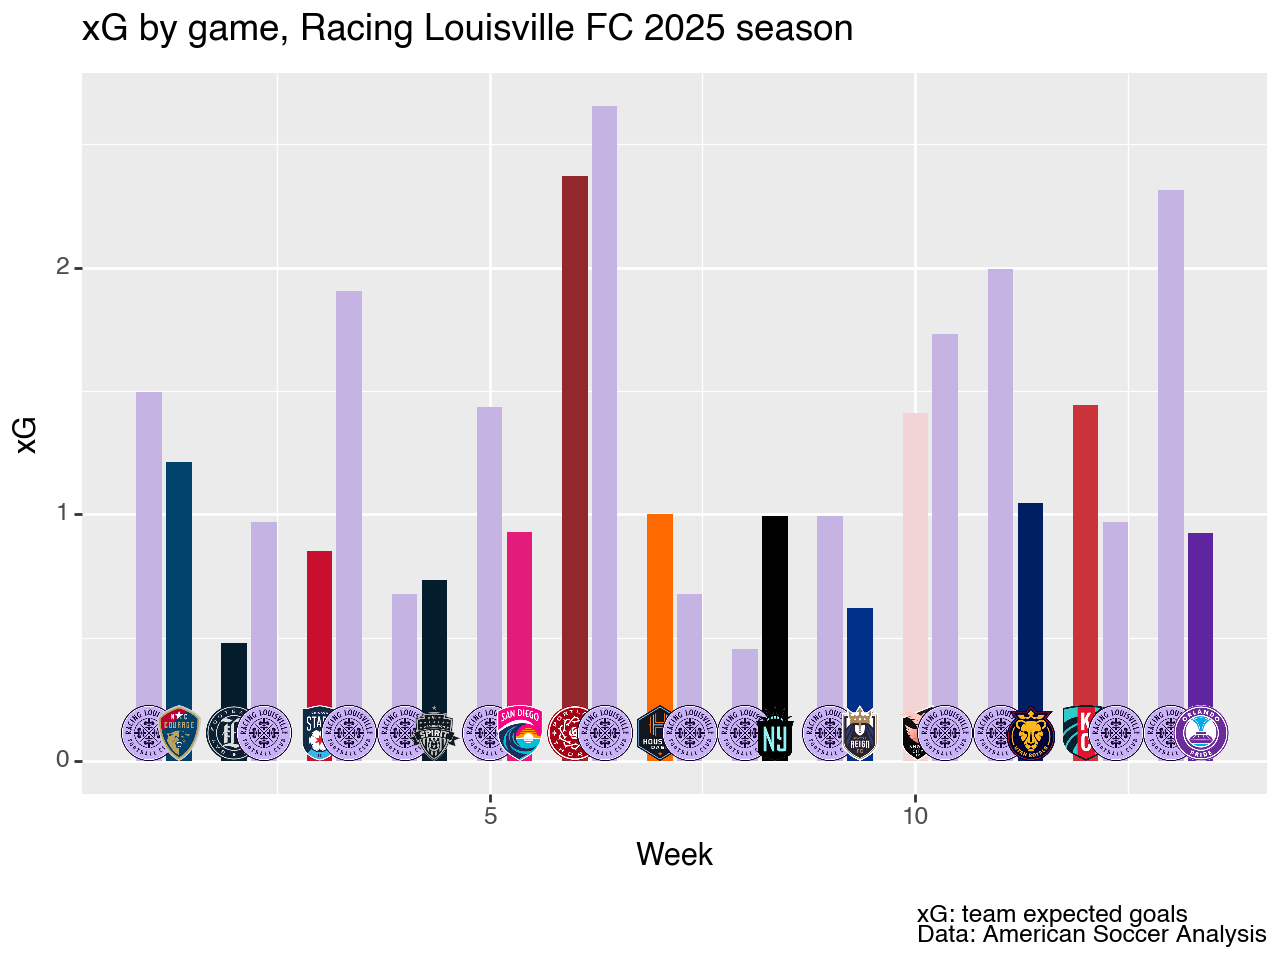

<Figure Size: (640 x 480)>

In [15]:
make_season_xg_plot(team_name="Racing Louisville FC")

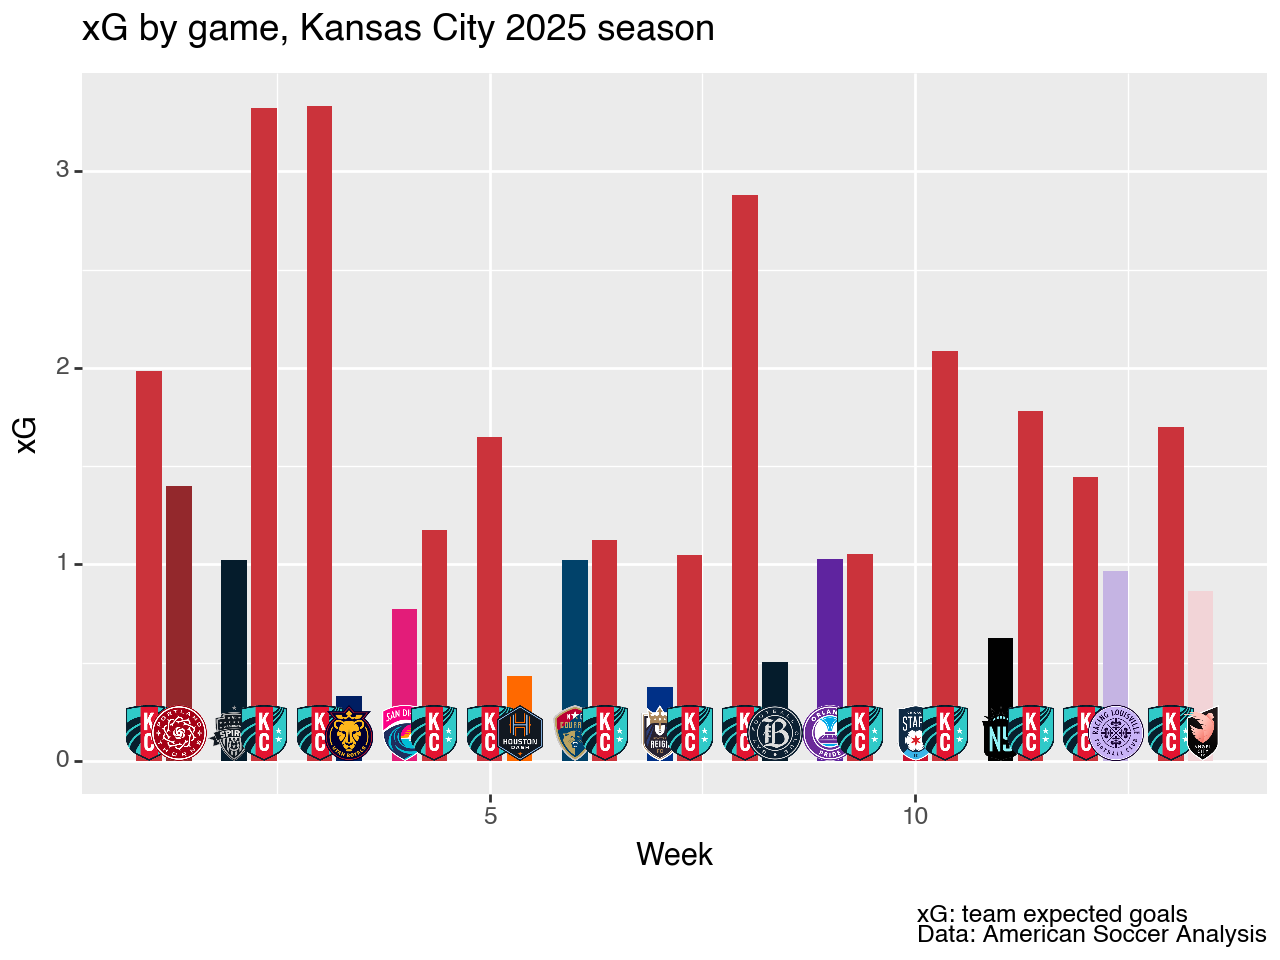

<Figure Size: (640 x 480)>

In [16]:
make_season_xg_plot(team_name="Kansas City")

In [17]:
def make_season_xgd_plot(league_name="nwsl", season_name="2025"):

    team_df = asa_client.get_team_xgoals(
        leagues=league_name,
        season=season_name,
        home_adjusted=True,
    )
    team_df = decorate_team_ids(team_df)
    team_df["xgoal_difference_per_game"] = (
        team_df.xgoal_difference / team_df.count_games
    )

    team_df = team_df.sort_values(
        "xgoal_difference_per_game", ascending=False
    ).reset_index(drop=True)

    plot = (
        ggplot(
            team_df,
            aes(x="team", y="xgoal_difference_per_game", fill="team"),
        )
        + geom_col()
        + scale_fill_manual(nwsl_primary_colors, guide=None)
        + scale_x_discrete(limits=team_df.team)
        + geom_image(aes(image="team_logo"))
        + labs(
            y="xGD",
            title=f"Average expected goal differential by team, NWSL 2025 season through week {team_df.count_games.min()}",
            caption="""
        xGD here measures expected goals - expected goals allowed by team per game, averaged over the season.
        xGD is adjusted for the share of home games played. 
        Data: American Soccer Analysis""",
        )
    )

    return plot

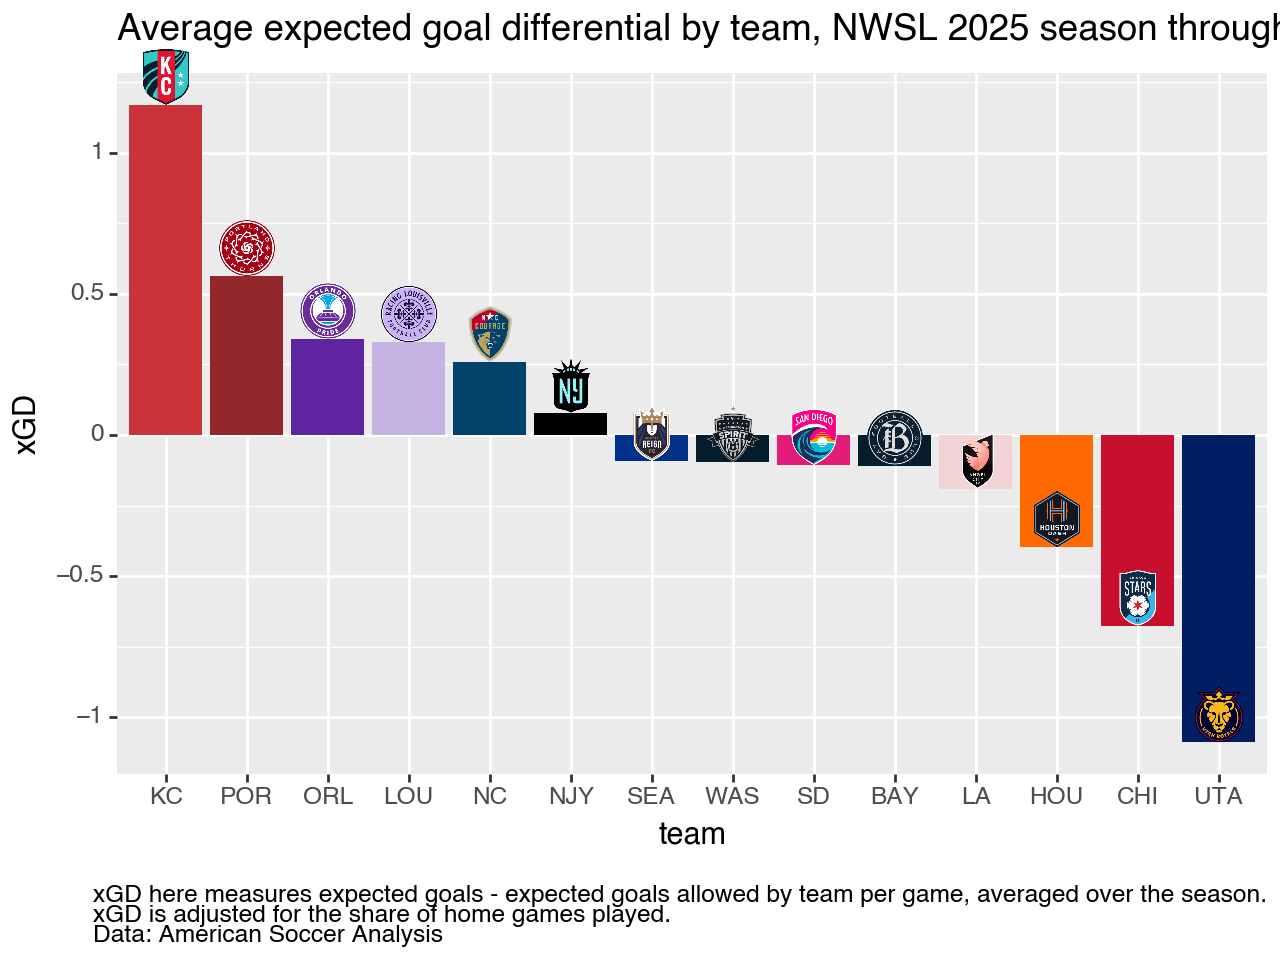

<Figure Size: (640 x 480)>

In [18]:
make_season_xgd_plot(league_name="nwsl", season_name="2025")

In [19]:
help(asa_client.get_team_goals_added)

Help on method get_team_goals_added in module itscalledsoccer.client:

get_team_goals_added(leagues: Union[str, List[str]] = ['nwsl', 'mls', 'uslc', 'usl1', 'usls', 'nasl', 'mlsnp'], **kwargs) -> pandas.core.frame.DataFrame method of itscalledsoccer.client.AmericanSoccerAnalysis instance
    Retrieves a DataFrame containing team g+ data meeting the specified conditions.
    
    Args:
        leagues (Union[str, List[str]], optional): Leagues on which to filter. Accepts a string or list of strings. Defaults to LEAGUES.
    
    Keyword Args:
        team_ids (Union[str, List[str]]): Team IDs on which to filter. Cannot be combined with team_names. Accepts a string or list of strings.
        team_names (Union[str, List[str]]): Team names on which to filter. Partial matches and abbreviations are accepted. Cannot be combined with team_ids. Accepts a string or list of strings.
        season_name (Union[str, List[str]]): Name(s)/year(s) of seasons. Cannot be combined with a date range. Acc

In [20]:
asa_client.get_team_goals_added(
    leagues="nwsl", season="2025", gamestate_trunc=["-1", "0"]
)

,team_id,minutes,data
0,315VnJ759x,789,"[{'action_type': 'Dribbling', 'num_actions_for..."
1,4JMAk47qKg,875,"[{'action_type': 'Receiving', 'num_actions_for..."
2,4wM4rZdqjB,459,"[{'action_type': 'Fouling', 'num_actions_for':..."
3,7vQ7BBzqD1,830,"[{'action_type': 'Interrupting', 'num_actions_..."
4,7VqG1lYMvW,630,"[{'action_type': 'Fouling', 'num_actions_for':..."
5,aDQ0lzvQEv,912,"[{'action_type': 'Receiving', 'num_actions_for..."
6,eV5D2w9QKn,877,"[{'action_type': 'Claiming', 'num_actions_for'..."
7,eV5DR6YQKn,679,"[{'action_type': 'Dribbling', 'num_actions_for..."
8,KPqjw8PQ6v,971,"[{'action_type': 'Interrupting', 'num_actions_..."
9,kRQa8JOqKZ,888,"[{'action_type': 'Passing', 'num_actions_for':..."


In [21]:
games_df = asa_client.get_games(
    leagues="nwsl", seasons="2025", team_names="Racing Louisville FC"
)
games_df

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,expanded_minutes,season_name,matchday,attendance,knockout_game,status,last_updated_utc
0,vzqoKNrkqa,2025-06-21 00:00:00 UTC,2,0,eV5DR6YQKn,XVqKeVKM01,7VqGdjdQvW,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,100,2025,13,5469,False,FullTime,2025-06-21 02:15:41 UTC
1,7VqGbYm65v,2025-06-14 23:30:00 UTC,4,2,4wM4rZdqjB,eV5DR6YQKn,KPqj32nQ6v,xW5p3L0Mg1,vzqo3mNqap,kRQa4GoqKZ,103,2025,12,11500,False,FullTime,2025-06-19 06:21:07 UTC
2,p6qbjWeBq0,2025-06-07 00:34:00 UTC,3,2,eV5DR6YQKn,eV5D2w9QKn,e7Mz8Eeqr0,BLMvra8Mxe,kRQa4GoqKZ,9vQ2YGaqK6,98,2025,11,3951,False,FullTime,2025-06-07 02:38:19 UTC
3,BLMvj2lOMx,2025-05-25 02:00:00 UTC,2,3,kRQa8JOqKZ,eV5DR6YQKn,eVq3J465WO,7vQ7xbOMD1,9YqdZ39MvJ,kRQa4GoqKZ,104,2025,10,16740,False,FullTime,2025-05-31 17:29:53 UTC
4,KXMeZ6er56,2025-05-17 17:00:00 UTC,0,1,eV5DR6YQKn,7vQ7BBzqD1,NWMWpvj5lz,BLMvra8Mxe,kRQa4GoqKZ,OlMlY7P5Lz,101,2025,9,3039,False,FullTime,2025-05-24 13:02:24 UTC
5,7vQ7bja2qD,2025-05-10 00:00:00 UTC,1,0,eV5DR6YQKn,raMyrr25d2,KAqBb1vqbg,BLMvra8Mxe,kRQa4GoqKZ,9vQ2r1LQK6,104,2025,8,5495,False,FullTime,2025-05-15 07:23:36 UTC
6,9z5kjk9jMA,2025-05-03 01:58:00 UTC,1,2,4JMAk47qKg,eV5DR6YQKn,gOMno2X5wN,0x5g6ojM7O,KPqjdAEM6v,kRQa4GoqKZ,99,2025,7,5765,False,FullTime,2025-05-10 00:22:22 UTC
7,2lqRpdZ0Mr,2025-04-27 20:00:00 UTC,3,3,Pk5LeeNqOW,eV5DR6YQKn,jYQJ3wEMGR,p6qbX06M0G,XVqKEk0M01,kRQa4GoqKZ,110,2025,6,16219,False,FullTime,2025-05-04 21:20:53 UTC
8,jYQJmLDPqG,2025-04-19 19:00:00 UTC,1,4,eV5DR6YQKn,7VqG1lYMvW,KPqj32nQ6v,BLMvra8Mxe,kRQa4GoqKZ,zeQZzPgQKw,105,2025,5,4431,False,FullTime,2025-04-24 14:48:57 UTC
9,NWMWp4Ej5l,2025-04-12 21:00:00 UTC,0,2,eV5DR6YQKn,aDQ0lzvQEv,2vQ1Bo8MrA,BLMvra8Mxe,kRQa4GoqKZ,9YqdzzjMvJ,102,2025,4,7886,False,FullTime,2025-04-18 15:23:13 UTC


# Xg Plot

Let's figure out how to make a plot like this from [Chris Henderson](https://bsky.app/profile/chris-awk.bsky.social/post/3lotophngxi2c)

![](https://cdn.bsky.app/img/feed_fullsize/plain/did:plc:dptgc5e5fm5y5engt5fdin5n/bafkreig45ohpd2mfeycifji2qrqoommaqkaqsnbuurutm55z4qn6islkty@jpeg)


In [22]:
decorate_team_ids(asa_client.get_games(game_ids=games_df.game_id[0]))

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,...,season_name,matchday,attendance,knockout_game,status,last_updated_utc,home_team,home_team_logo,away_team,away_team_logo
0,vzqoKNrkqa,2025-06-21 00:00:00 UTC,2,0,eV5DR6YQKn,XVqKeVKM01,7VqGdjdQvW,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,...,2025,13,5469,False,FullTime,2025-06-21 02:15:41 UTC,LOU,https://american-soccer-analysis-headshots.s3....,ORL,https://american-soccer-analysis-headshots.s3....


In [23]:
shots_df = decorate_player_ids(
    decorate_team_ids(
        asa_client._get_stats(
            game_id="BLMvj2lOMx", type="shots", entity="games", leagues="nwsl"
        )
    )
)

shots_df

,game_id,period_id,expanded_minute,game_minute,team_id,shooter_player_id,assist_player_id,shot_location_x,shot_location_y,shot_end_location_x,...,assist_through_ball,assist_cross,pattern_of_play,shot_order,team,team_logo,shooter_player,shooter_player_headshot,assist_player,assist_player_headshot
0,BLMvj2lOMx,1,2,1,eV5DR6YQKn,odMXGw2oQY,0,77.9,38.9,86.2,...,0,0,Set piece,37,LOU,https://american-soccer-analysis-headshots.s3....,Kayla Fischer,https://american-soccer-analysis-headshots.s3....,NaN,https://american-soccer-analysis-headshots.s3....
1,BLMvj2lOMx,1,5,4,eV5DR6YQKn,odMXGw2oQY,0Oq6wZexQ6,92.2,39.1,94.1,...,0,0,Regular,76,LOU,https://american-soccer-analysis-headshots.s3....,Kayla Fischer,https://american-soccer-analysis-headshots.s3....,Janine Sonis,https://american-soccer-analysis-headshots.s3....
2,BLMvj2lOMx,1,21,20,eV5DR6YQKn,odMXGw2oQY,0,87.4,54.0,97.5,...,0,0,Regular,382,LOU,https://american-soccer-analysis-headshots.s3....,Kayla Fischer,https://american-soccer-analysis-headshots.s3....,NaN,https://american-soccer-analysis-headshots.s3....
3,BLMvj2lOMx,1,23,22,eV5DR6YQKn,2lqRk0vaQr,0,88.5,50.0,100.0,...,0,0,Penalty,390,LOU,https://american-soccer-analysis-headshots.s3....,Taylor Flint,https://american-soccer-analysis-headshots.s3....,NaN,https://american-soccer-analysis-headshots.s3....
4,BLMvj2lOMx,1,25,24,kRQa8JOqKZ,NPqxA2zjQ9,2lqRJk0Jqr,98.2,39.4,99.7,...,0,1,Corner,402,LA,https://american-soccer-analysis-headshots.s3....,Mary Vignola,https://american-soccer-analysis-headshots.s3....,Moriya Miyabi,https://american-soccer-analysis-headshots.s3....
5,BLMvj2lOMx,1,25,24,eV5DR6YQKn,2lqRk0vaQr,0Oq6wZexQ6,92.0,55.0,100.0,...,0,1,Regular,425,LOU,https://american-soccer-analysis-headshots.s3....,Taylor Flint,https://american-soccer-analysis-headshots.s3....,Janine Sonis,https://american-soccer-analysis-headshots.s3....
6,BLMvj2lOMx,1,26,25,eV5DR6YQKn,KPqjBzzRq6,NWMWV0NYQl,89.2,80.8,94.0,...,0,0,Regular,438,LOU,https://american-soccer-analysis-headshots.s3....,Emma Sears,https://american-soccer-analysis-headshots.s3....,Courtney Petersen,https://american-soccer-analysis-headshots.s3....
7,BLMvj2lOMx,1,29,28,eV5DR6YQKn,KPqjBzzRq6,KPqjKkoPQ6,75.1,47.2,100.0,...,0,0,Regular,485,LOU,https://american-soccer-analysis-headshots.s3....,Emma Sears,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....
8,BLMvj2lOMx,1,30,29,kRQa8JOqKZ,p6qboEVwQ0,ljqEJe3YQx,85.6,63.4,88.8,...,0,0,Regular,499,LA,https://american-soccer-analysis-headshots.s3....,Alyssa Thompson,https://american-soccer-analysis-headshots.s3....,Kennedy Fuller,https://american-soccer-analysis-headshots.s3....
9,BLMvj2lOMx,1,31,30,kRQa8JOqKZ,KPqjKvrYQ6,2lqRJk0Jqr,88.8,31.3,98.8,...,0,0,Regular,537,LA,https://american-soccer-analysis-headshots.s3....,Gisele Thompson,https://american-soccer-analysis-headshots.s3....,Moriya Miyabi,https://american-soccer-analysis-headshots.s3....


In [24]:
shots_df.groupby("team")["shot_xg"].sum()

team
LA     1.4111
LOU    1.9124
Name: shot_xg, dtype: float64

/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this w

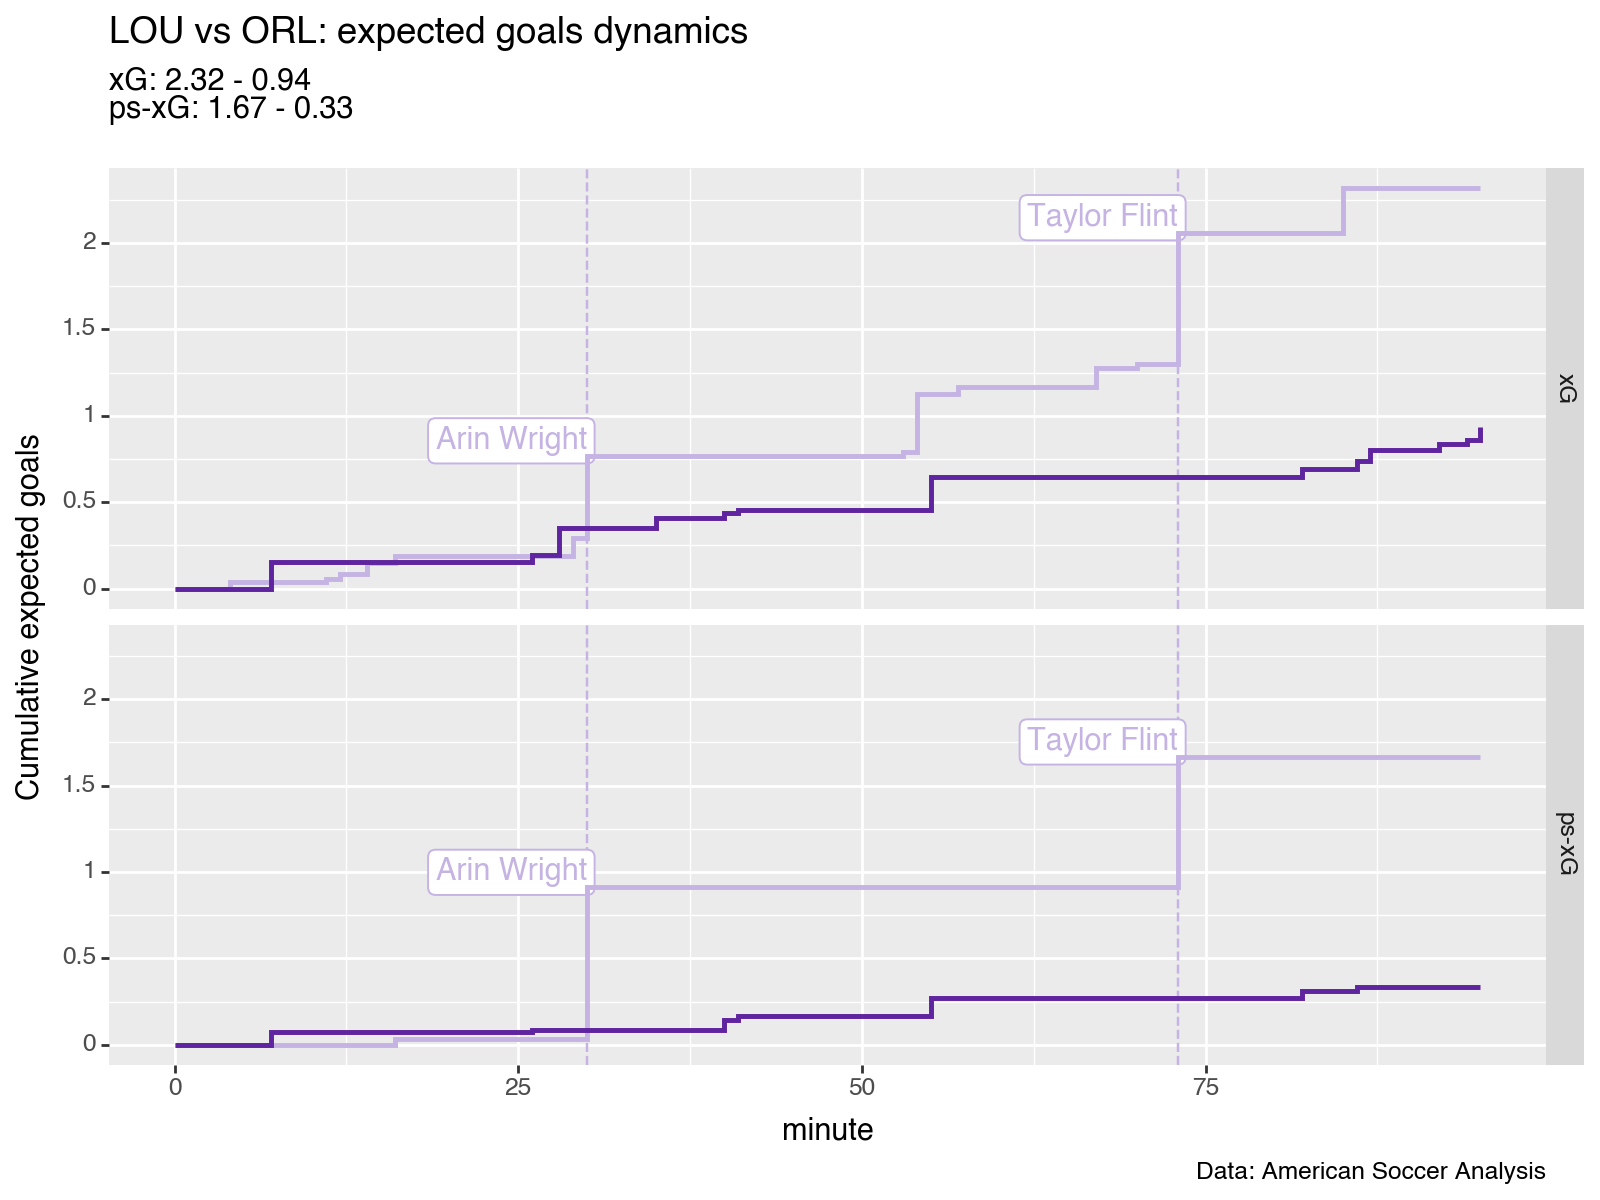

<Figure Size: (800 x 600)>

In [25]:
def process_shots_df(shots_df, team):
    subset_df = pd.DataFrame()
    subset_df["expanded_minute"] = np.arange(
        0, shots_df.expanded_minute.max() + 1, dtype="int64"
    )
    subset_df["team"] = team

    subset_df = subset_df.merge(shots_df, on=["expanded_minute", "team"], how="left")

    subset_df[["shot_xg", "shot_psxg"]] = subset_df[["shot_xg", "shot_psxg"]].fillna(0)

    subset_df["xG"] = subset_df.groupby("team").shot_xg.cumsum()
    subset_df["ps-xG"] = subset_df.groupby("team").shot_psxg.cumsum()

    return subset_df


def make_game_xg_plot(
    game_id="7vQ7bja2qD", metric=["xG", "ps-xG"], non_penalty=False, fig_size=(8, 6)
):
    shots_df = decorate_player_ids(
        decorate_team_ids(
            asa_client._get_stats(
                game_id=game_id, type="shots", entity="games", leagues="nwsl"
            )
        )
    )

    if non_penalty:
        shots_df = shots_df.query("pattern_of_play != 'Penalty'")

    if type(metric) == str:
        metric = [metric]

    # metric_pretty = {"xg": "xG", "psxg": "ps-xG"}[metric.lower()]

    game_df = decorate_team_ids(asa_client.get_games(game_ids=game_id))

    home_df = process_shots_df(shots_df, game_df.home_team[0])
    away_df = process_shots_df(shots_df, game_df.away_team[0])

    xg_df = pd.concat((home_df, away_df), ignore_index=True)

    xg_melt_df = xg_df.melt(
        id_vars=["expanded_minute", "team", "shooter_player", "goal"],
        value_vars=["xG", "ps-xG"],
        var_name="xg_type",
        value_name="xg_value",
    )

    xg_melt_df.xg_type = pd.Categorical(xg_melt_df.xg_type, categories=["xG", "ps-xG"])

    plot_df = xg_melt_df.loc[xg_melt_df.xg_type.isin(metric), :]

    plot = (
        ggplot(
            plot_df,
            aes(
                x="expanded_minute",
                y=f"xg_value",
                color="team",
            ),
        )
        + geom_vline(
            aes(xintercept="expanded_minute", color="team"),
            data=plot_df.query("goal > 0"),
            linetype="--",
        )
        + geom_label(
            aes(x="expanded_minute", y=f"xg_value", label="shooter_player"),
            data=plot_df.query("goal > 0"),
            # adjust_text=dict(
            #     # only_move={"pull": "y+"},
            #     # max_move=(5,5),
            #     arrowprops=dict(arrowstyle="->"),
            # ),
            va="bottom",
            ha="right",
        )
        + geom_step(size=1)
        + scale_color_manual(nwsl_primary_colors, guide=None)
        + facet_grid("xg_type ~ .")
        + theme(figure_size=fig_size)
        + labs(
            title=f"{game_df.home_team[0]} vs {game_df.away_team[0]}: expected goals dynamics",
            subtitle=f"""xG: {shots_df.loc[shots_df.team == game_df.home_team[0],:].shot_xg.sum():.2f} - {shots_df.loc[shots_df.team == game_df.away_team[0],:].shot_xg.sum():.2f}
ps-xG: {shots_df.loc[shots_df.team == game_df.home_team[0],:].shot_psxg.sum():.2f} - {shots_df.loc[shots_df.team == game_df.away_team[0],:].shot_psxg.sum():.2f}
""",
            caption="""Data: American Soccer Analysis""",
            y="Cumulative expected goals",
            x="minute",
        )
    )

    summary_df = (
        shots_df.pivot_table(
            values=["shot_xg", "shot_psxg", "game_id"],
            index=["team", "shooter_player"],
            aggfunc={
                "shot_xg": "sum",
                "shot_psxg": "sum",
                "game_id": "count",
            },
            # margins=True
        )
        .sort_values(["team", "shot_xg"], ascending=False)
        .rename(
            columns={
                "game_id": "shot count",
                "shot_xg": "xG total",
                "shot_psxg": "ps-xG total",
            }
        )
    )

    return plot, summary_df


plot, summary_df = make_game_xg_plot(game_id=games_df.game_id[0])
plot

/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this w

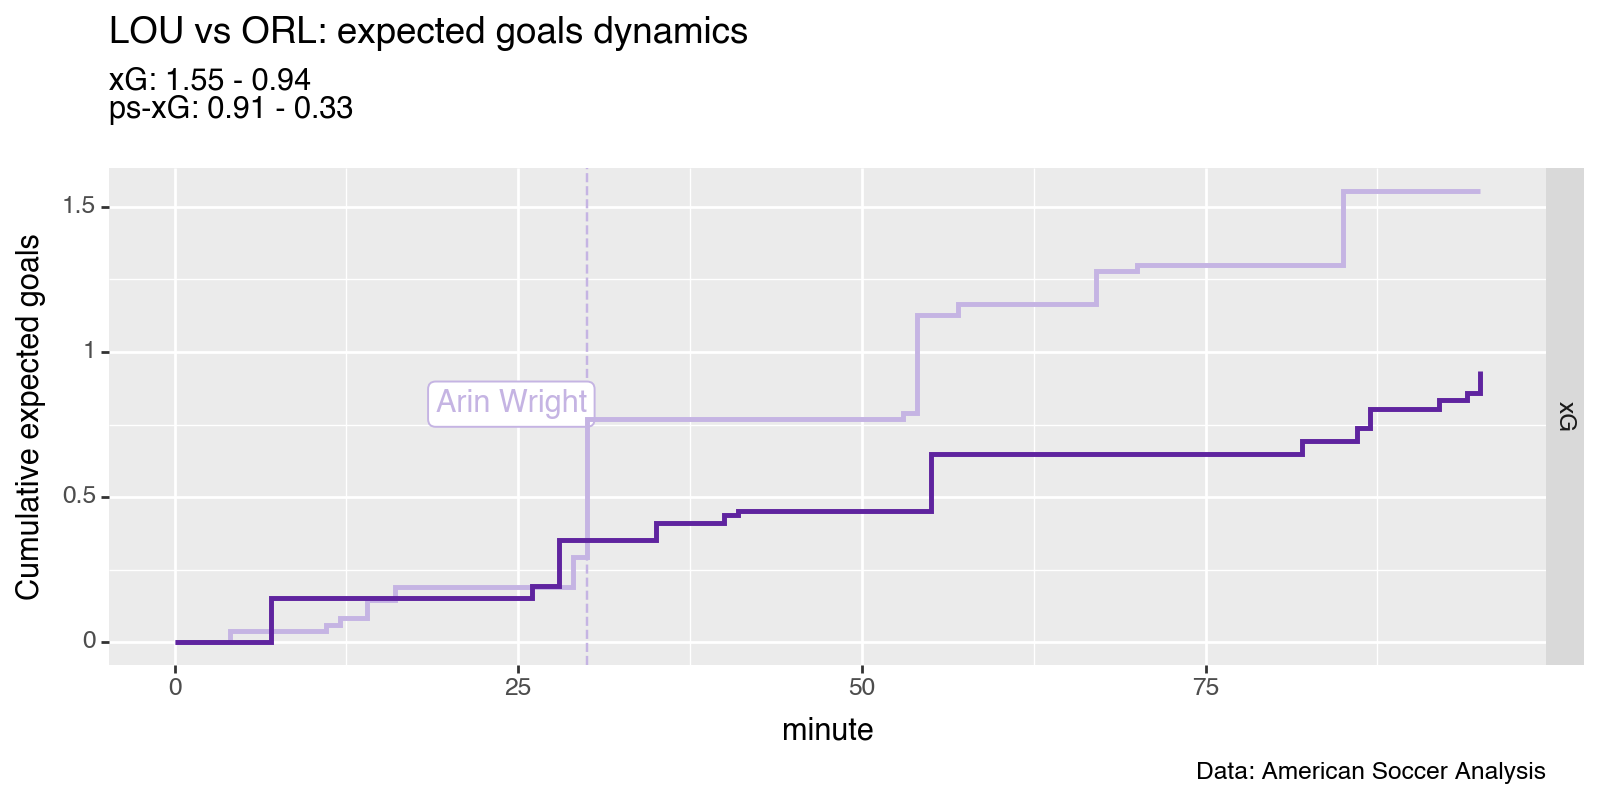

(<Figure Size: (800 x 400)>,
                         shot count  ps-xG total  xG total
 team shooter_player                                      
 ORL  Barbra Banda                9       0.2491    0.6212
      Summer Yates                1       0.0000    0.1578
      Marta                       1       0.0000    0.0549
      Angelina                    3       0.0826    0.0434
      Morgan Gautrat              1       0.0000    0.0326
      Simone Jackson              1       0.0000    0.0251
 LOU  Arin Wright                 1       0.8773    0.4746
      Ary Borges                  1       0.0000    0.3369
      Sarah Weber                 2       0.0000    0.2956
      Savannah DeMelo             5       0.0340    0.2830
      Emma Sears                  2       0.0000    0.1251
      Courtney Petersen           1       0.0000    0.0207
      Taylor Flint                1       0.0000    0.0186)

In [26]:
make_game_xg_plot(
    game_id=games_df.game_id[0], metric="xG", non_penalty=True, fig_size=(8, 4)
)

/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/utils.py:596: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this w

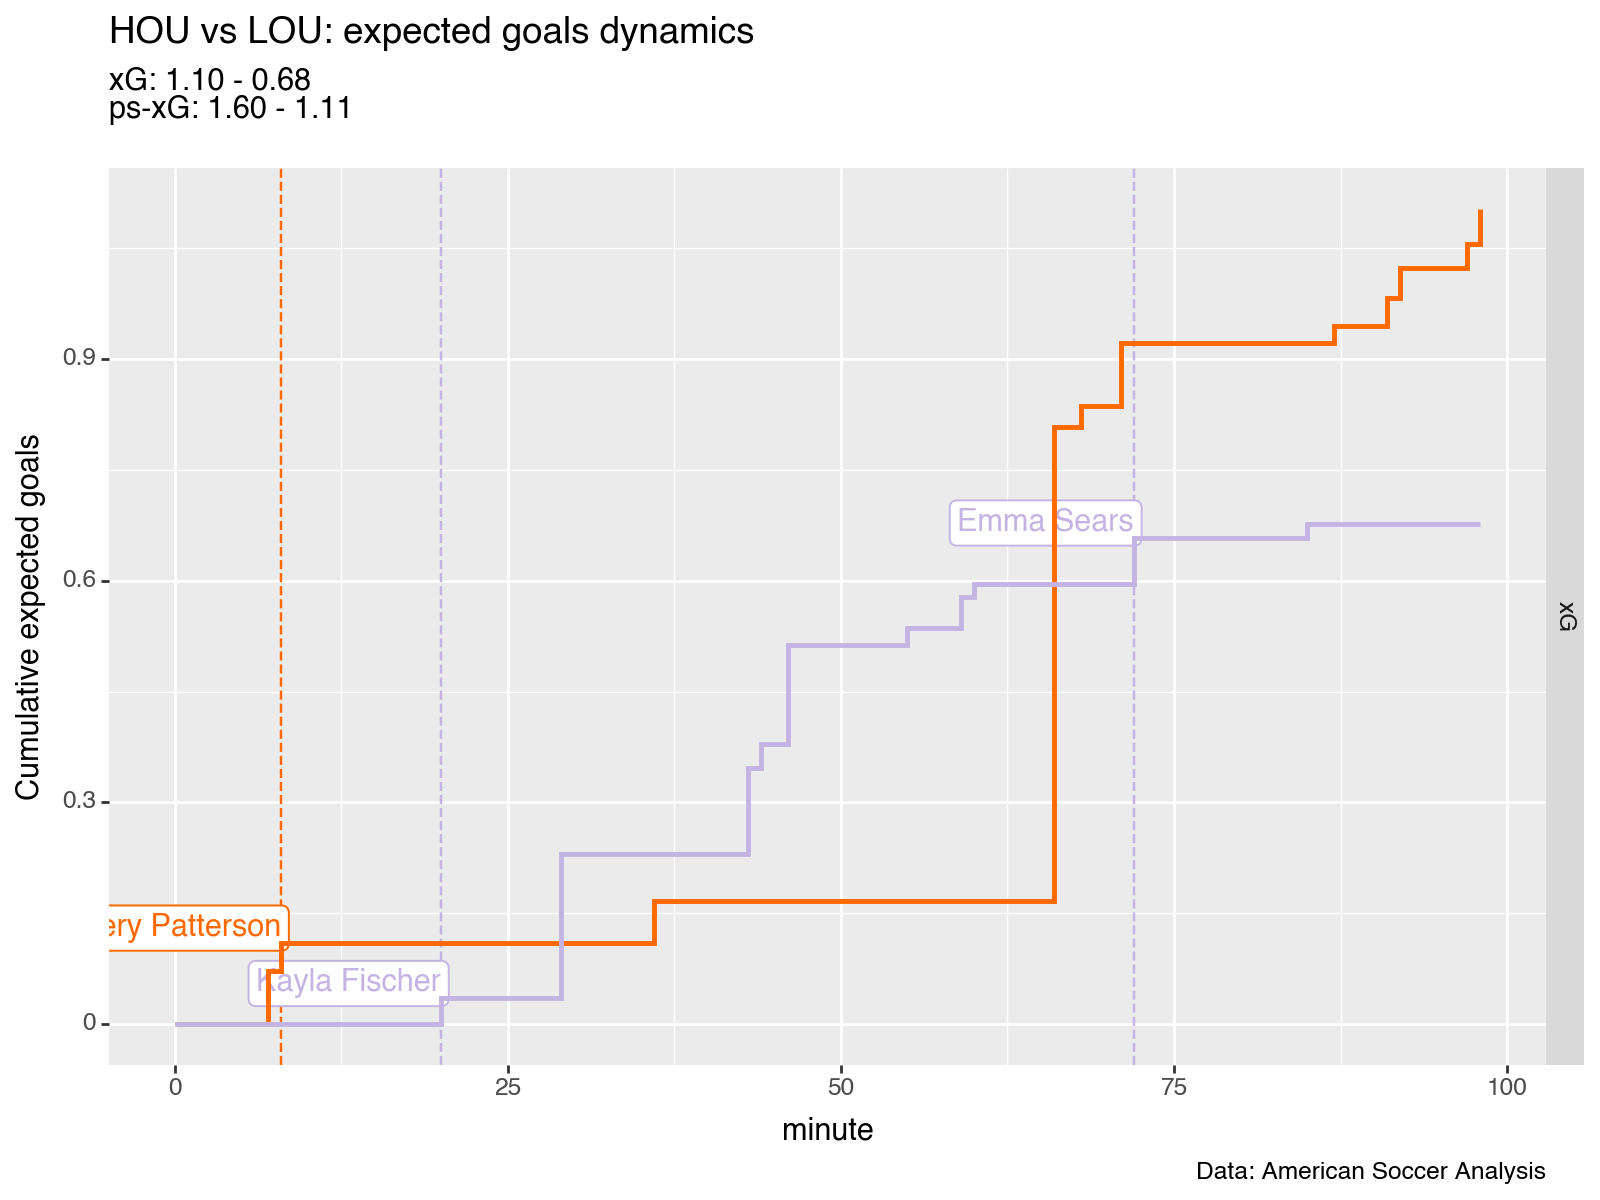

(<Figure Size: (800 x 600)>,
                         shot count  ps-xG total  xG total
 team shooter_player                                      
 LOU  Kayla Fischer               2       0.3215    0.2298
      Emma Sears                  3       0.7839    0.2191
      Janine Sonis                1       0.0000    0.1172
      Courtney Petersen           1       0.0000    0.0425
      Marisa DiGrande             2       0.0000    0.0361
      Savannah DeMelo             2       0.0000    0.0323
 HOU  Avery Patterson             5       1.0322    0.5089
      Bárbara Olivieri            1       0.4911    0.3572
      Messiah Bright              1       0.0000    0.0563
      Evelina Duljan              1       0.0000    0.0473
      Natalie Jacobs              1       0.0000    0.0415
      Michelle Alozie             1       0.0742    0.0371
      Delanie Sheehan             1       0.0000    0.0318
      Yazmeen Ryan                1       0.0000    0.0229)

In [27]:
make_game_xg_plot(game_id="9z5kjk9jMA", metric="xG", non_penalty=True)

In [28]:
summary_df

shot count  ps-xG total  xG total
team shooter_player                                      
ORL  Barbra Banda                9       0.2491    0.6212
     Summer Yates                1       0.0000    0.1578
     Marta                       1       0.0000    0.0549
     Angelina                    3       0.0826    0.0434
     Morgan Gautrat              1       0.0000    0.0326
     Simone Jackson              1       0.0000    0.0251
LOU  Taylor Flint                2       0.7545    0.7800
     Arin Wright                 1       0.8773    0.4746
     Ary Borges                  1       0.0000    0.3369
     Sarah Weber                 2       0.0000    0.2956
     Savannah DeMelo             5       0.0340    0.2830
     Emma Sears                  2       0.0000    0.1251
     Courtney Petersen           1       0.0000    0.0207

In [29]:
shots_df = decorate_player_ids(
    decorate_team_ids(
        asa_client._get_stats(
            game_id=games_df.game_id[0], type="shots", entity="games", leagues="nwsl"
        )
    )
)

shots_df.T

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
game_id,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,...,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa,vzqoKNrkqa
period_id,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
expanded_minute,4,7,11,12,14,16,26,28,29,30,...,70,73,82,85,86,87,92,94,95,95
game_minute,3,6,10,11,13,15,25,27,28,29,...,64,67,76,79,80,81,86,88,89,89
team_id,eV5DR6YQKn,XVqKeVKM01,eV5DR6YQKn,eV5DR6YQKn,eV5DR6YQKn,eV5DR6YQKn,XVqKeVKM01,XVqKeVKM01,eV5DR6YQKn,eV5DR6YQKn,...,eV5DR6YQKn,eV5DR6YQKn,XVqKeVKM01,eV5DR6YQKn,XVqKeVKM01,XVqKeVKM01,XVqKeVKM01,XVqKeVKM01,XVqKeVKM01,XVqKeVKM01
shooter_player_id,a35rnK125L,BLMv7oZO5x,2lqRk0vaQr,KPqjKkoPQ6,KPqjKkoPQ6,KPqjKkoPQ6,BLMv7oZO5x,315VXdEbQ9,KPqjBzzRq6,2lqRkmXAQr,...,NWMWV0NYQl,2lqRk0vaQr,BLMv7oZO5x,a35rnK125L,BLMv7oZO5x,BLMv7oZO5x,315VeoRVM9,kRQao0715K,BLMv7oZO5x,BLMv7oZO5x
assist_player_id,KPqjKkoPQ6,4JMAak3kMK,KPqjKkoPQ6,0,2lqRk0vaQr,0,ljqE241EQx,0Oq6w6D6Q6,KPqjKkoPQ6,NWMWV0NYQl,...,2lqRk0vaQr,0,315VeoRVM9,NWMWV0NYQl,0,gpMOol9nMz,0,ljqE241EQx,315VeoRVM9,0
shot_location_x,88.4,83.7,68.3,77.2,80.3,82.6,75.6,92.5,81.5,99.2,...,78.6,88.5,92.0,97.1,80.4,78.4,82.4,82.2,86.7,86.7
shot_location_y,44.2,63.0,36.3,61.7,51.5,83.1,58.1,53.1,62.7,54.0,...,72.8,50.0,29.8,51.9,67.2,53.4,47.7,34.6,39.7,39.7
shot_end_location_x,100.0,98.1,100.0,100.0,81.6,99.3,98.9,100.0,84.6,100.0,...,86.2,100.0,98.9,100.0,98.5,100.0,100.0,91.1,91.9,100.0


In [30]:
shots_df.pivot_table(
    values=["shot_xg", "shot_psxg"],
    index=["team", "shooter_player"],
    aggfunc={
        "shot_xg": "sum",
        "shot_psxg": "sum",
    },
    # margins=True
).sort_values(["team", "shot_xg"], ascending=False)

shot_psxg  shot_xg
team shooter_player                       
ORL  Barbra Banda          0.2491   0.6212
     Summer Yates          0.0000   0.1578
     Marta                 0.0000   0.0549
     Angelina              0.0826   0.0434
     Morgan Gautrat        0.0000   0.0326
     Simone Jackson        0.0000   0.0251
LOU  Taylor Flint          0.7545   0.7800
     Arin Wright           0.8773   0.4746
     Ary Borges            0.0000   0.3369
     Sarah Weber           0.0000   0.2956
     Savannah DeMelo       0.0340   0.2830
     Emma Sears            0.0000   0.1251
     Courtney Petersen     0.0000   0.0207

In [31]:
make_game_xg_plot(game_id=games_df.game_id[0], metric="psxg")

PlotnineError: 'Faceting variables must have at least one value'

In [32]:
games_df = asa_client.get_games(
    seasons="2025", leagues="nwsl", team_names="Racing Louisville FC"
)
games_df

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,expanded_minutes,season_name,matchday,attendance,knockout_game,status,last_updated_utc
0,vzqoKNrkqa,2025-06-21 00:00:00 UTC,2,0,eV5DR6YQKn,XVqKeVKM01,7VqGdjdQvW,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,100,2025,13,5469,False,FullTime,2025-06-21 02:15:41 UTC
1,7VqGbYm65v,2025-06-14 23:30:00 UTC,4,2,4wM4rZdqjB,eV5DR6YQKn,KPqj32nQ6v,xW5p3L0Mg1,vzqo3mNqap,kRQa4GoqKZ,103,2025,12,11500,False,FullTime,2025-06-19 06:21:07 UTC
2,p6qbjWeBq0,2025-06-07 00:34:00 UTC,3,2,eV5DR6YQKn,eV5D2w9QKn,e7Mz8Eeqr0,BLMvra8Mxe,kRQa4GoqKZ,9vQ2YGaqK6,98,2025,11,3951,False,FullTime,2025-06-07 02:38:19 UTC
3,BLMvj2lOMx,2025-05-25 02:00:00 UTC,2,3,kRQa8JOqKZ,eV5DR6YQKn,eVq3J465WO,7vQ7xbOMD1,9YqdZ39MvJ,kRQa4GoqKZ,104,2025,10,16740,False,FullTime,2025-05-31 17:29:53 UTC
4,KXMeZ6er56,2025-05-17 17:00:00 UTC,0,1,eV5DR6YQKn,7vQ7BBzqD1,NWMWpvj5lz,BLMvra8Mxe,kRQa4GoqKZ,OlMlY7P5Lz,101,2025,9,3039,False,FullTime,2025-05-24 13:02:24 UTC
5,7vQ7bja2qD,2025-05-10 00:00:00 UTC,1,0,eV5DR6YQKn,raMyrr25d2,KAqBb1vqbg,BLMvra8Mxe,kRQa4GoqKZ,9vQ2r1LQK6,104,2025,8,5495,False,FullTime,2025-05-15 07:23:36 UTC
6,9z5kjk9jMA,2025-05-03 01:58:00 UTC,1,2,4JMAk47qKg,eV5DR6YQKn,gOMno2X5wN,0x5g6ojM7O,KPqjdAEM6v,kRQa4GoqKZ,99,2025,7,5765,False,FullTime,2025-05-10 00:22:22 UTC
7,2lqRpdZ0Mr,2025-04-27 20:00:00 UTC,3,3,Pk5LeeNqOW,eV5DR6YQKn,jYQJ3wEMGR,p6qbX06M0G,XVqKEk0M01,kRQa4GoqKZ,110,2025,6,16219,False,FullTime,2025-05-04 21:20:53 UTC
8,jYQJmLDPqG,2025-04-19 19:00:00 UTC,1,4,eV5DR6YQKn,7VqG1lYMvW,KPqj32nQ6v,BLMvra8Mxe,kRQa4GoqKZ,zeQZzPgQKw,105,2025,5,4431,False,FullTime,2025-04-24 14:48:57 UTC
9,NWMWp4Ej5l,2025-04-12 21:00:00 UTC,0,2,eV5DR6YQKn,aDQ0lzvQEv,2vQ1Bo8MrA,BLMvra8Mxe,kRQa4GoqKZ,9YqdzzjMvJ,102,2025,4,7886,False,FullTime,2025-04-18 15:23:13 UTC


In [33]:
make_game_xg_plot(game_id=games_df.game_id[1], metric="psxg")

PlotnineError: 'Faceting variables must have at least one value'

In [34]:
make_game_xg_plot(game_id=games_df.game_id[2], metric="psxg")

PlotnineError: 'Faceting variables must have at least one value'

In [35]:
make_game_xg_plot(game_id=games_df.game_id[3], metric="psxg")

PlotnineError: 'Faceting variables must have at least one value'

In [36]:
make_game_xg_plot(game_id=games_df.game_id[4], metric="psxg")

PlotnineError: 'Faceting variables must have at least one value'

In [37]:
shots_df

,game_id,period_id,expanded_minute,game_minute,team_id,shooter_player_id,assist_player_id,shot_location_x,shot_location_y,shot_end_location_x,...,assist_through_ball,assist_cross,pattern_of_play,shot_order,team,team_logo,shooter_player,shooter_player_headshot,assist_player,assist_player_headshot
0,vzqoKNrkqa,1,4,3,eV5DR6YQKn,a35rnK125L,KPqjKkoPQ6,88.4,44.2,100.0,...,0,1,Set piece,46,LOU,https://american-soccer-analysis-headshots.s3....,Sarah Weber,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....
1,vzqoKNrkqa,1,7,6,XVqKeVKM01,BLMv7oZO5x,4JMAak3kMK,83.7,63.0,98.1,...,0,0,Fastbreak,116,ORL,https://american-soccer-analysis-headshots.s3....,Barbra Banda,https://american-soccer-analysis-headshots.s3....,Marta,https://american-soccer-analysis-headshots.s3....
2,vzqoKNrkqa,1,11,10,eV5DR6YQKn,2lqRk0vaQr,KPqjKkoPQ6,68.3,36.3,100.0,...,0,0,Regular,167,LOU,https://american-soccer-analysis-headshots.s3....,Taylor Flint,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....
3,vzqoKNrkqa,1,12,11,eV5DR6YQKn,KPqjKkoPQ6,0,77.2,61.7,100.0,...,0,0,Regular,186,LOU,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....,NaN,https://american-soccer-analysis-headshots.s3....
4,vzqoKNrkqa,1,14,13,eV5DR6YQKn,KPqjKkoPQ6,2lqRk0vaQr,80.3,51.5,81.6,...,0,0,Regular,202,LOU,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....,Taylor Flint,https://american-soccer-analysis-headshots.s3....
5,vzqoKNrkqa,1,16,15,eV5DR6YQKn,KPqjKkoPQ6,0,82.6,83.1,99.3,...,0,0,Free kick,235,LOU,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....,NaN,https://american-soccer-analysis-headshots.s3....
6,vzqoKNrkqa,1,26,25,XVqKeVKM01,BLMv7oZO5x,ljqE241EQx,75.6,58.1,98.9,...,0,0,Regular,393,ORL,https://american-soccer-analysis-headshots.s3....,Barbra Banda,https://american-soccer-analysis-headshots.s3....,Angelina,https://american-soccer-analysis-headshots.s3....
7,vzqoKNrkqa,1,28,27,XVqKeVKM01,315VXdEbQ9,0Oq6w6D6Q6,92.5,53.1,100.0,...,0,1,Regular,420,ORL,https://american-soccer-analysis-headshots.s3....,Summer Yates,https://american-soccer-analysis-headshots.s3....,Ally Watt,https://american-soccer-analysis-headshots.s3....
8,vzqoKNrkqa,1,29,28,eV5DR6YQKn,KPqjBzzRq6,KPqjKkoPQ6,81.5,62.7,84.6,...,0,0,Fastbreak,449,LOU,https://american-soccer-analysis-headshots.s3....,Emma Sears,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....
9,vzqoKNrkqa,1,30,29,eV5DR6YQKn,2lqRkmXAQr,NWMWV0NYQl,99.2,54.0,100.0,...,0,1,Corner,454,LOU,https://american-soccer-analysis-headshots.s3....,Arin Wright,https://american-soccer-analysis-headshots.s3....,Courtney Petersen,https://american-soccer-analysis-headshots.s3....


In [38]:
xg_df = make_game_xg_plot()
xg_df[["expanded_minute", "team", "shot_xg", "shot_psxg", "xg_cum", "psxg_cum"]]

TypeError: tuple indices must be integers or slices, not list

In [ ]:
xg_df.T

,0,1,2,3,4,5,6,7,8,9,...,195,196,197,198,199,200,201,202,203,204
expanded_minute,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,100,101
team,LOU,LOU,LOU,LOU,LOU,LOU,LOU,LOU,LOU,LOU,...,NJY,NJY,NJY,NJY,NJY,NJY,NJY,NJY,NJY,NJY
game_id,NaN,NaN,NaN,NaN,NaN,7vQ7bja2qD,NaN,NaN,7vQ7bja2qD,NaN,...,NaN,NaN,7vQ7bja2qD,NaN,NaN,NaN,7vQ7bja2qD,NaN,NaN,7vQ7bja2qD
period_id,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,2.0,NaN,NaN,2.0
game_minute,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,7.0,NaN,...,NaN,NaN,85.0,NaN,NaN,NaN,89.0,NaN,NaN,92.0
team_id,NaN,NaN,NaN,NaN,NaN,eV5DR6YQKn,NaN,NaN,eV5DR6YQKn,NaN,...,NaN,NaN,raMyrr25d2,NaN,NaN,NaN,raMyrr25d2,NaN,NaN,raMyrr25d2
shooter_player_id,NaN,NaN,NaN,NaN,NaN,2lqRkmXAQr,NaN,NaN,KPqjKkoPQ6,NaN,...,NaN,NaN,kRQao2bk5K,NaN,NaN,NaN,2lqRj1OLqr,NaN,NaN,kRQao2bk5K
assist_player_id,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,2lqRkmXAQr,NaN,...,NaN,NaN,gOMnREd8Mw,NaN,NaN,NaN,gOMn6X8BMw,NaN,NaN,0
shot_location_x,NaN,NaN,NaN,NaN,NaN,68.3,NaN,NaN,69.8,NaN,...,NaN,NaN,79.3,NaN,NaN,NaN,81.0,NaN,NaN,75.6
shot_location_y,NaN,NaN,NaN,NaN,NaN,36.7,NaN,NaN,41.6,NaN,...,NaN,NaN,49.1,NaN,NaN,NaN,51.6,NaN,NaN,59.1


In [ ]:
xg_df.query("goal > 0")

,expanded_minute,team,game_id,period_id,game_minute,team_id,shooter_player_id,assist_player_id,shot_location_x,shot_location_y,...,assist_cross,pattern_of_play,shot_order,team_logo,shooter_player,shooter_player_headshot,assist_player,assist_player_headshot,xg_cum,psxg_cum
65,64,LOU,7vQ7bja2qD,2.0,55.0,eV5DR6YQKn,2lqRk0vaQr,KPqjKkoPQ6,75.6,39.3,...,0.0,Regular,970.0,https://american-soccer-analysis-headshots.s3....,Taylor Flint,https://american-soccer-analysis-headshots.s3....,Savannah DeMelo,https://american-soccer-analysis-headshots.s3....,0.4138,0.3175


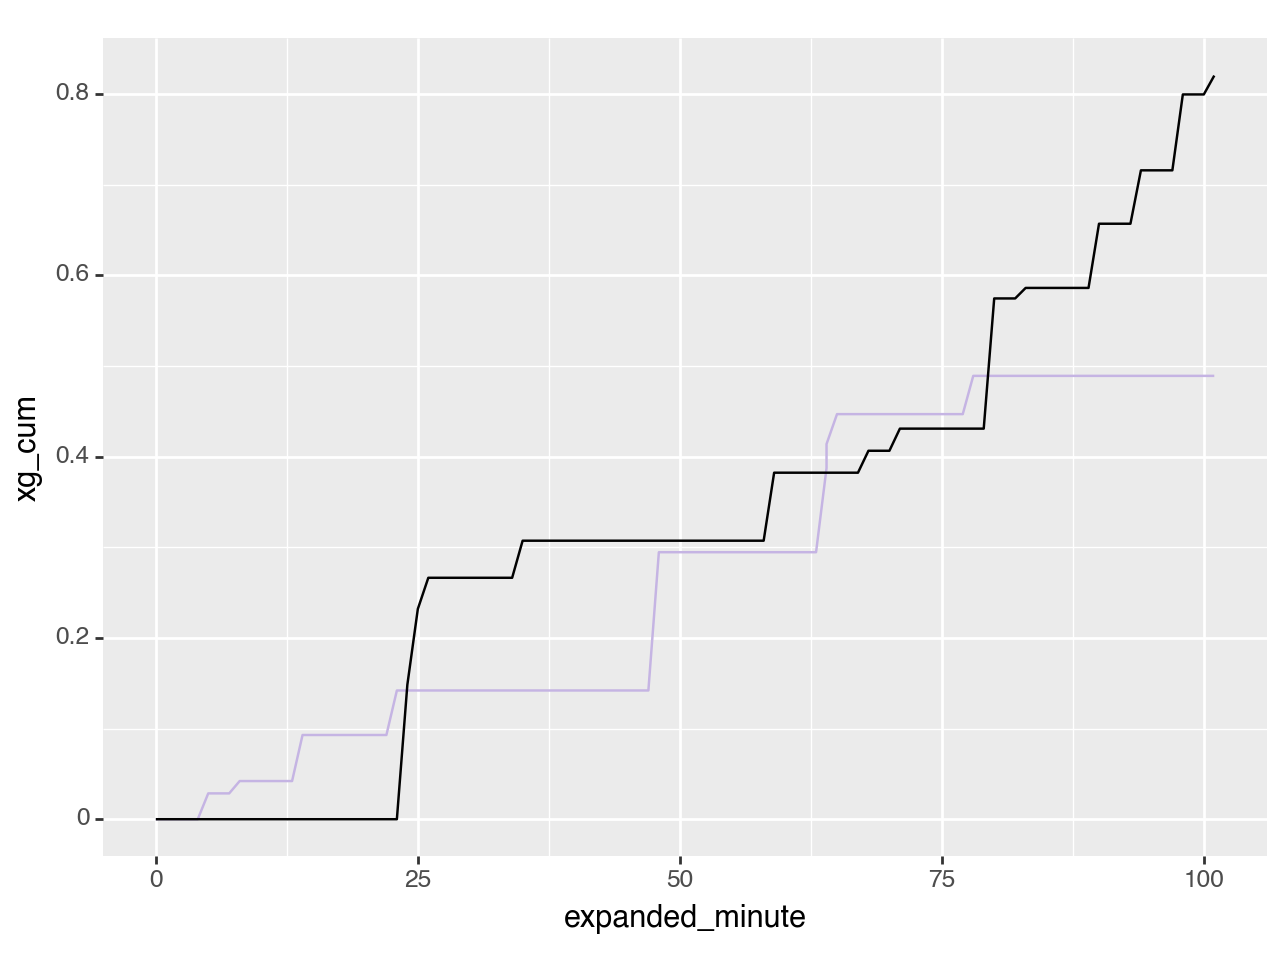

<Figure Size: (640 x 480)>

In [ ]:
(
    ggplot(
        xg_df,
        aes(
            x="expanded_minute",
            y="xg_cum",
            color="team",
        ),
    )
    + geom_line()
    + scale_color_manual(nwsl_primary_colors, guide=None)
)

In [ ]:
shots_df.pivot_table(
    values=["shot_xg", "shot_psxg"],
    index=["team", "shooter_player"],
    aggfunc={
        "shot_xg": "sum",
        "shot_psxg": "sum",
    },
    # margins=True
).sort_values(["team", "shot_xg"], ascending=False)

shot_psxg  shot_xg
team shooter_player                      
NJY  Esther González      0.0162   0.2819
     Geyse                0.0918   0.1586
     Midge Purce          0.0000   0.1483
     Sofia Cook           0.0284   0.0837
     Ella Stevens         0.0000   0.0708
     Sarah Schupansky     0.0870   0.0409
     Jaelin Howell        0.0118   0.0244
     Lilly Reale          0.0000   0.0116
LOU  Janine Sonis         0.1607   0.1525
     Kayla Fischer        0.0000   0.0928
     Katie O'Kane         0.0576   0.0913
     Taylor Flint         0.1034   0.0773
     Emma Sears           0.0000   0.0330
     Arin Wright          0.0000   0.0285
     Savannah DeMelo      0.0356   0.0136

In [ ]:
print(
    f"""
Home avg xpoints: {games_df.query("home_team == 'LOU'").home_xpoints.mean()}
Away avg xpoints: {games_df.query("away_team == 'LOU'").away_xpoints.mean()}
Total avg xpoints: { (games_df.query("home_team == 'LOU'").home_xpoints.sum() + games_df.query("away_team == 'LOU'").away_xpoints.sum()) / len(games_df)}
"""
)

print(
    f"""
Home avg points: {games_df.query("home_team == 'LOU'").home_points.mean()}
Away avg points: {games_df.query("away_team == 'LOU'").away_points.mean()}
Total avg points: { (games_df.query("home_team == 'LOU'").home_points.sum() + games_df.query("away_team == 'LOU'").away_points.sum()) / len(games_df)}
"""
)


Home avg xpoints: 1.5606666666666669
Away avg xpoints: 1.6709999999999998
Total avg xpoints: 1.6237142857142857


Home avg points: 0.3333333333333333
Away avg points: 1.75
Total avg points: 1.1428571428571428



In [ ]:
# a35rj2dA5L

In [ ]:
game_flow_df = decorate_team_ids(
    asa_client._get_stats(
        game_id="7vQ7bja2qD", type="game-flow", entity="games", leagues="nwsl"
    )
)

game_flow_df

,game_id,period_id,expanded_minute,home_team_id,home_team_value,away_team_id,away_team_value,scoring_team_id,scoring_player_id,pattern_of_play,home_team,home_team_logo,away_team,away_team_logo,scoring_team,scoring_team_logo
0,7vQ7bja2qD,1,0,eV5DR6YQKn,0.0000,raMyrr25d2,0.0026,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
1,7vQ7bja2qD,1,1,eV5DR6YQKn,0.0000,raMyrr25d2,0.0120,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
2,7vQ7bja2qD,1,2,eV5DR6YQKn,0.0383,raMyrr25d2,0.0125,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
3,7vQ7bja2qD,1,3,eV5DR6YQKn,0.0015,raMyrr25d2,0.0069,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
4,7vQ7bja2qD,1,4,eV5DR6YQKn,0.0002,raMyrr25d2,0.0079,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,7vQ7bja2qD,2,100,eV5DR6YQKn,0.0256,raMyrr25d2,-0.0029,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
97,7vQ7bja2qD,2,101,eV5DR6YQKn,0.0039,raMyrr25d2,0.0244,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
98,7vQ7bja2qD,2,102,eV5DR6YQKn,0.0051,raMyrr25d2,0.0119,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN
99,7vQ7bja2qD,2,103,eV5DR6YQKn,0.0039,raMyrr25d2,0.0088,NaN,NaN,NaN,LOU,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,NaN,NaN


/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/layer.py:344: PlotnineWarning: position_stack : Removed 1 rows containing missing values.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/layer.py:344: PlotnineWarning: position_stack : Removed 1 rows containing missing values.
/opt/homebrew/Caskroom/mambaforge/base/envs/soph/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_image : Removed 100 rows containing missing values.


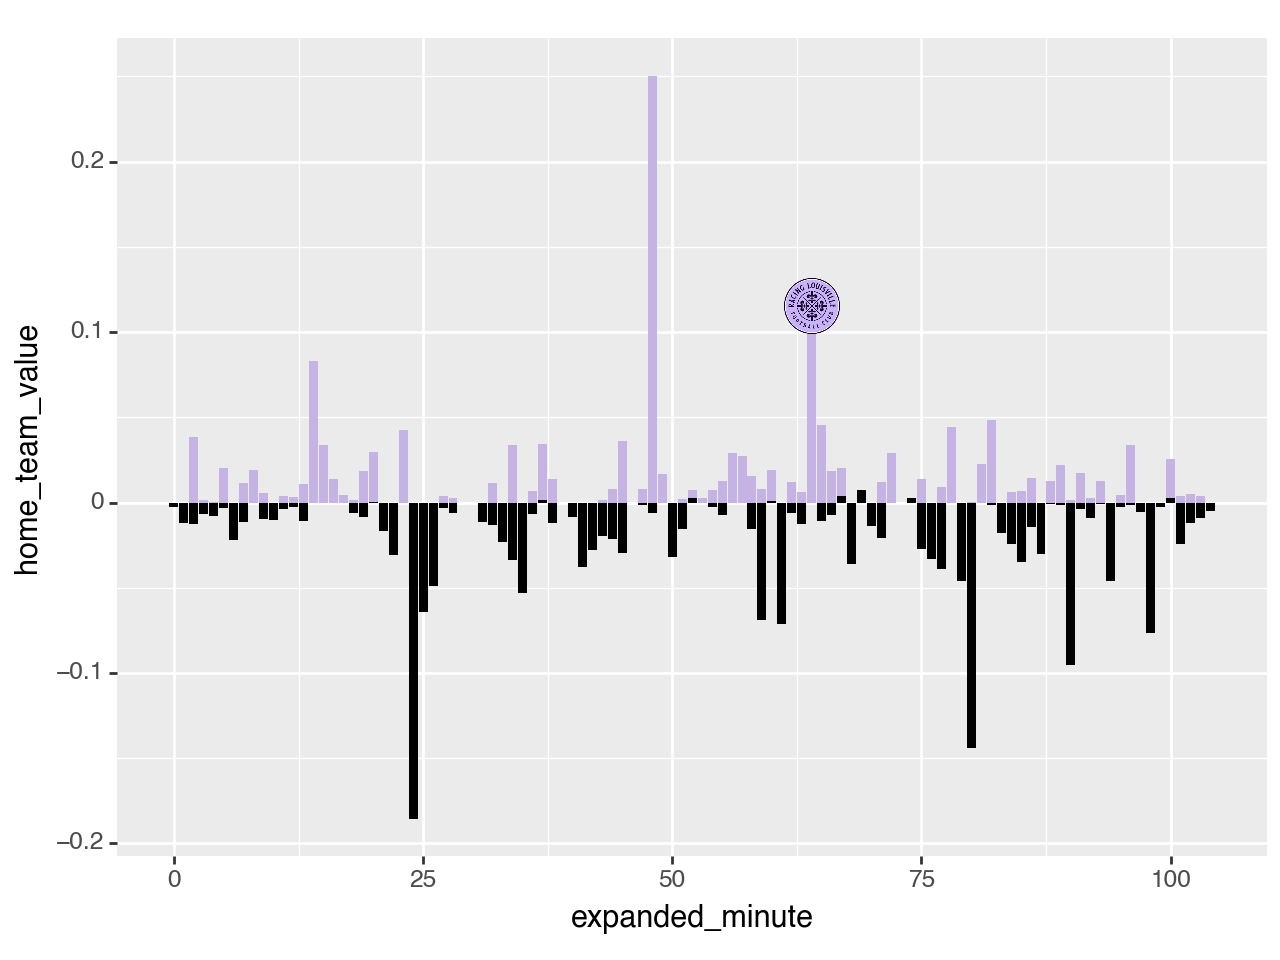

<Figure Size: (640 x 480)>

In [ ]:
(
    ggplot(
        game_flow_df,
        aes(x="expanded_minute"),
    )
    + geom_col(aes(y="home_team_value", fill="home_team"))
    + geom_image(aes(y="home_team_value", image="scoring_team_logo"))
    + geom_col(aes(y="-away_team_value", fill="away_team"))
    + scale_fill_manual(nwsl_primary_colors, guide=None)
    # + scale_x_discrete(limits=team_df.team)
    # #     + geom_col(
    # #         aes(x="matchday+0.35", y="away_team_xgoals", fill="away_team"), width=0.3
    # #     )
    # + geom_image(aes(image="team_logo"))
    # #     + geom_image(aes(x="matchday+0.35", y=0, image="away_team_logo"))
    # + labs(
    #     y="xGD",
    #     title="xGD by team, NWSL 2025 season through week 7",
    #     caption="""
    # xGD here measures expected goals - expected goals allowed by team per game, averaged over the season.
    # xGD is adjusted for the share of home games played.
    # Data: American Soccer Analysis""",
    # )
)

In [ ]:
shots_df = decorate_team_ids(
    asa_client._get_stats(
        game_id="7vQ7bja2qD", type="shots", entity="games", leagues="nwsl"
    )
)
shots_df.T

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
game_id,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,...,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD,7vQ7bja2qD
period_id,1,1,1,1,1,1,1,1,1,2,...,2,2,2,2,2,2,2,2,2,2
expanded_minute,5,8,14,23,24,25,26,35,48,59,...,65,68,71,78,80,83,90,94,98,101
game_minute,4,7,13,22,23,24,25,34,47,50,...,56,59,62,69,71,74,81,85,89,92
team_id,eV5DR6YQKn,eV5DR6YQKn,eV5DR6YQKn,eV5DR6YQKn,raMyrr25d2,raMyrr25d2,raMyrr25d2,raMyrr25d2,eV5DR6YQKn,raMyrr25d2,...,eV5DR6YQKn,raMyrr25d2,raMyrr25d2,eV5DR6YQKn,raMyrr25d2,raMyrr25d2,raMyrr25d2,raMyrr25d2,raMyrr25d2,raMyrr25d2
shooter_player_id,2lqRkmXAQr,KPqjKkoPQ6,2lqRk0vaQr,KAqBRVn7qb,XVqKWLrWq0,9vQ223OaQK,kRQao2bk5K,2vQ1eNl0Qr,0Oq6wZexQ6,9vQ223OaQK,...,KPqjBzzRq6,kRQao2bk5K,gOMnREd8Mw,KAqBRVn7qb,kRQao2bk5K,0Oq63DazQ6,e7Mzlyyeqr,kRQao2bk5K,2lqRj1OLqr,kRQao2bk5K
assist_player_id,0,2lqRkmXAQr,0,odMXGw2oQY,9vQ223OaQK,XVqKWLrWq0,9vQ223OaQK,0,KPqjKkoPQ6,kRQao2bk5K,...,odMXGw2oQY,0Oq63DazQ6,0Oq63DazQ6,0,e7Mzlyyeqr,0,a35rKEnoqL,gOMnREd8Mw,gOMn6X8BMw,0
shot_location_x,68.3,69.8,85.5,81.6,88.4,81.5,94.3,76.9,91.4,95.3,...,88.1,78.0,80.2,75.7,95.8,71.5,87.9,79.3,81.0,75.6
shot_location_y,36.7,41.6,53.4,35.2,37.1,48.5,63.6,28.6,68.4,58.4,...,27.0,73.8,75.9,37.0,58.9,62.6,34.5,49.1,51.6,59.1
shot_end_location_x,100.0,98.5,100.0,98.4,91.5,98.6,100.0,98.6,95.6,100.0,...,100.0,100.0,98.8,98.4,100.0,100.0,100.0,100.0,99.3,99.1


In [ ]:
shots_df.groupby("team")[["shot_xg", "shot_psxg"]].sum()

,shot_xg,shot_psxg
team,,
LOU,0.4890,0.3573
NJY,0.8202,0.2352


In [ ]:
asa_client._get_stats()

In [ ]:
racing_df = decorate_team_ids(asa_client.get_games(team_names="Racing Louisville FC"))

In [ ]:
racing_df["total_score"] = racing_df.home_score + racing_df.away_score

racing_df.query("home_team == 'LOU'").sort_values("total_score", ascending=False)

,game_id,date_time_utc,home_score,away_score,home_team_id,away_team_id,referee_id,stadium_id,home_manager_id,away_manager_id,...,matchday,attendance,knockout_game,status,last_updated_utc,home_team,home_team_logo,away_team,away_team_logo,total_score
28,Pk5LDR2m5O,2024-04-20 21:00:00 UTC,5,1,eV5DR6YQKn,eV5D2w9QKn,a35rXmAQL6,BLMvra8Mxe,kRQa4GoqKZ,7vQ7DeLMD1,...,5,11365,False,FullTime,2024-04-27 21:40:59 UTC,LOU,https://american-soccer-analysis-headshots.s3....,UTA,https://american-soccer-analysis-headshots.s3....,6
2,jYQJmLDPqG,2025-04-19 19:00:00 UTC,1,4,eV5DR6YQKn,7VqG1lYMvW,KPqj32nQ6v,BLMvra8Mxe,kRQa4GoqKZ,zeQZzPgQKw,...,5,4431,False,FullTime,2025-04-24 14:48:57 UTC,LOU,https://american-soccer-analysis-headshots.s3....,SD,https://american-soccer-analysis-headshots.s3....,5
116,2vQ1lwlwqr,2021-04-26 22:00:00 UTC,2,3,eV5DR6YQKn,zeQZeazqKw,2lqRokLQr0,BLMvra8Mxe,wvq9mKNqWn,2lqREma5r0,...,4,3742,False,FullTime,2021-04-30 18:34:08 UTC,LOU,https://american-soccer-analysis-headshots.s3....,NC,https://american-soccer-analysis-headshots.s3....,5
89,gpMO6R2RQz,2022-03-25 23:30:00 UTC,2,3,eV5DR6YQKn,4JMAk47qKg,BLMvDxAqxe,BLMvra8Mxe,2lqReDJ5r0,0Oq6BpAq6D,...,2,3800,False,FullTime,2022-03-31 18:27:30 UTC,LOU,https://american-soccer-analysis-headshots.s3....,HOU,https://american-soccer-analysis-headshots.s3....,5
15,0Oq6e0Xx56,2024-08-31 23:30:00 UTC,2,3,eV5DR6YQKn,7vQ7BBzqD1,aDQ03rGqEv,BLMvra8Mxe,KXMew2kq64,KPqjYOy56v,...,18,5011,False,FullTime,2024-09-09 12:12:35 UTC,LOU,https://american-soccer-analysis-headshots.s3....,SEA,https://american-soccer-analysis-headshots.s3....,5
77,odMXLvyeMY,2022-06-12 00:00:00 UTC,2,3,eV5DR6YQKn,kRQa8JOqKZ,gpMO6A2Qzy,BLMvra8Mxe,2lqReDJ5r0,eV5D17RqKn,...,7,6139,False,FullTime,2022-06-15 11:35:48 UTC,LOU,https://american-soccer-analysis-headshots.s3....,LA,https://american-soccer-analysis-headshots.s3....,5
55,gjMNArkBQK,2023-05-17 23:30:00 UTC,3,2,eV5DR6YQKn,4wM4rZdqjB,a35r3kGqL6,BLMvra8Mxe,2lqReDJ5r0,jYQJJBGQGR,...,2,4303,False,FullTime,2023-05-18 01:56:08 UTC,LOU,https://american-soccer-analysis-headshots.s3....,KC,https://american-soccer-analysis-headshots.s3....,5
34,gpMO0l7y5z,2023-10-06 23:30:00 UTC,3,2,eV5DR6YQKn,XVqKeVKM01,4wM4mGg5jB,BLMvra8Mxe,2lqReDJ5r0,jYQJJ1VQGR,...,21,6455,False,FullTime,2023-10-12 18:35:11 UTC,LOU,https://american-soccer-analysis-headshots.s3....,ORL,https://american-soccer-analysis-headshots.s3....,5
32,xW5pJg9lQg,2024-03-16 20:00:00 UTC,2,2,eV5DR6YQKn,XVqKeVKM01,aDQ03rGqEv,BLMvra8Mxe,kRQa4GoqKZ,jYQJJ1VQGR,...,1,6123,False,FullTime,2024-03-21 23:41:12 UTC,LOU,https://american-soccer-analysis-headshots.s3....,ORL,https://american-soccer-analysis-headshots.s3....,4
103,e7MzXWnPqr,2021-08-08 19:00:00 UTC,3,1,eV5DR6YQKn,4wM4rZdqjB,ljqEyb4qx0,BLMvra8Mxe,wvq9mKNqWn,Xj5YzJyqbd,...,12,5843,False,FullTime,2021-08-14 01:04:39 UTC,LOU,https://american-soccer-analysis-headshots.s3....,KC,https://american-soccer-analysis-headshots.s3....,4


In [ ]:
help(asa_client.get_game_xgoals)

Help on method get_game_xgoals in module itscalledsoccer.client:

get_game_xgoals(leagues: Union[str, List[str]] = ['nwsl', 'mls', 'uslc', 'usl1', 'usls', 'nasl', 'mlsnp'], **kwargs) -> pandas.core.frame.DataFrame method of itscalledsoccer.client.AmericanSoccerAnalysis instance
    Retrieves a DataFrame containing game xG data meeting the specified conditions.
    
    Args:
        leagues (Union[str, List[str]], optional): Leagues on which to filter. Accepts a string or list of strings. Defaults to LEAGUES.
    
    Keyword Args:
        game_ids (Union[str, List[str]]): Game IDs on which to filter. Accepts a string or list of strings.
        season_name (Union[str, List[str]]): Name(s)/year(s) of seasons. Cannot be combined with a date range. Accepts a string or list of strings.
        start_date (str): Start of a date range. Must be a string in YYYY-MM-DD format. Cannot be combined with season_name.
        end_date (str): End of a date range. Must be a string in YYYY-MM-DD forma

In [ ]:
asa_client.get_game_xgoals(season_name="2025", leagues="nwsl")

,game_id,date_time_utc,home_team_id,home_goals,home_team_xgoals,home_player_xgoals,away_team_id,away_goals,away_team_xgoals,away_player_xgoals,goal_difference,team_xgoal_difference,player_xgoal_difference,final_score_difference,home_xpoints,away_xpoints
0,raMyj2LO5d,2025-05-05 00:00:00 UTC,7VqG1lYMvW,2,1.8263,1.8287,315VnJ759x,1,0.5477,0.5477,1,1.2786,1.2810,1,2.411,0.398
1,gjMNpdn0qK,2025-05-04 17:00:00 UTC,raMyrr25d2,0,0.9649,0.9687,KPqjw8PQ6v,0,0.3747,0.3747,0,0.5902,0.5940,0,1.929,0.726
2,Pk5LpdmO5O,2025-05-04 02:00:00 UTC,eV5D2w9QKn,0,0.7930,0.7930,zeQZeazqKw,1,1.9566,2.0305,-1,-1.1636,-1.2375,-2,0.553,2.239
3,EGMPadeV5a,2025-05-03 23:30:00 UTC,Pk5LeeNqOW,1,1.3646,1.3892,XVqKeVKM01,0,1.2087,1.2223,1,0.1559,0.1669,1,1.464,1.266
4,315VpEZ9Q9,2025-05-03 02:30:00 UTC,7vQ7BBzqD1,1,0.3330,0.3330,4wM4rZdqjB,0,1.0446,1.0446,1,-0.7116,-0.7116,1,0.660,1.980
5,9z5kjk9jMA,2025-05-03 01:58:00 UTC,4JMAk47qKg,1,0.8201,0.8570,eV5DR6YQKn,2,0.7285,0.7287,-1,0.0917,0.1283,-1,1.402,1.219
6,wvq9b8awQW,2025-05-03 00:00:00 UTC,aDQ0lzvQEv,3,1.9606,2.0108,kRQa8JOqKZ,4,2.7142,2.7336,-1,-0.7536,-0.7228,-1,0.893,1.889
7,2lqRpdZ0Mr,2025-04-27 20:00:00 UTC,Pk5LeeNqOW,3,2.3731,2.3803,eV5DR6YQKn,3,2.6545,3.0996,0,-0.2814,-0.7192,0,1.211,1.544
8,vzqoKN9kqa,2025-04-27 02:00:00 UTC,315VnJ759x,1,1.5497,1.5518,7vQ7BBzqD1,1,1.0366,1.0366,0,0.5131,0.5153,0,1.783,0.949
9,gOMnALrXQw,2025-04-26 23:30:00 UTC,KPqjw8PQ6v,0,0.8347,0.8474,7VqG1lYMvW,2,0.9844,0.9887,-2,-0.1498,-0.1412,-3,1.189,1.486
